# PySpark Project
**Course: Large Scale Student Management**  
**Professor: Vania Marangozova**  
**Students: Daniel Beqaj, Eya Ridene**  

##### All the following analysis is conducted on our data sample (60 to 64) instead of the whole dataset.
---

In [2]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F
import time
from pyspark.storagelevel import StorageLevel
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

PATH_MACHINE_EVENTS = "../spark-data/machine_events/*.csv.gz"
PATH_JOB_EVENTS  = "../spark-data/job_events/*.csv.gz"
PATH_TASK_EVENTS = "../spark-data/task_events/*.csv.gz"
PATH_TASK_USAGE = "../spark-data/task_usage/*.csv.gz"

26/01/13 14:57:30 WARN Utils: Your hostname, LAPTOP-SMTR1LU7 resolves to a loopback address: 127.0.1.1; using 172.23.207.34 instead (on interface eth0)
26/01/13 14:57:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/13 14:57:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [1]:
# ----------------------------
# Parsing utilities
# ----------------------------
def to_int(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_long(x):
    return int(x) if x not in (None, "", "NULL") else None

def to_float(x):
    return float(x) if x not in (None, "", "NULL") else None

## Question 1 — *What is the distribution of the machines according to their CPU capacity?*

In *machine_events* we can find information about the machines of the system. <br>
Every row of the csv file contains an event recorded in a certain timestamp for a specific machine identified by its unique id. <br>
The information about a machine's capacity can be found in the fifth field, where the values are normalized between 0 and 1 in proportion to the maximum CPU capacity. <br>
For the distribution of the machines according to CPU, we need to take one single event that represent a unique machine. Otherwise, we risk to perturbate the real distribution by the occurrencies of events of some machines that change state frequently. <br>
More explanation can be found in the code comments.


In [4]:
machine_events_rdd = sc.textFile(PATH_MACHINE_EVENTS)

# Exploring the dataset of machine_events
print("\n" + "="*80)
print(f"Number of machine_events records: {machine_events_rdd.count()}")
print(f"First line : ")
print({machine_events_rdd.first()})
print(f"Type of the elements : {type(machine_events_rdd.first())}")

machine_CPUs_values = (
    machine_events_rdd
    .map(lambda line: line.split(",")[4])   # extract CPUs column
    .distinct()
)

print("\n" + "="*80)
print(f"Number of distinct values for CPUs: {machine_CPUs_values.count()}")
print("Values of CPUs:")
print(machine_CPUs_values.take(5))

distribution_machine_CPUs = (
    machine_events_rdd
    .map(lambda line: (line.split(",")[1],line.split(",")[4]))  # each element (machine_ID,capacity_CPU)
    .reduceByKey(lambda x1, w2: x1)                             # keeps only the first distinct machine_ID
    .map(lambda x: (x[1],1))                                    # only keep the CPUs for the distribution
    .reduceByKey(lambda a, b: a + b)
)

print("\n" + "="*80)
print("Distribution of the machines according to CPUs:")
print(distribution_machine_CPUs.take(5))




Number of machine_events records: 37780
First line : 
{'0,5,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493'}
Type of the elements : <class 'str'>

Number of distinct values for CPUs: 4
Values of CPUs:
['0.5', '0.25', '1', '']

Distribution of the machines according to CPUs:
[('0.5', 11632), ('0.25', 123), ('1', 796), ('', 32)]


---
## Question 2 — *What is the percentage of computational power lost due to maintenance (a machine went offline and reconnected later)?*
#### The computational power is proportional to both the CPU capacity and the unavailability period of machines.

According to the **Google Document**, there are three type of events in *machine_events*:
- *ADD* a machine to the cluster (0)
- *REMOVE* a machine from the cluster (1)
- *UPDATE* the capacity of a machine (2)

By definition, a machine goes offline when its *event_type* is 1 in *machine_events*. <br>
To answer this question, we need:
- Timestamp (field 0)
- Machine_ID (field 1)
- Event_type (field 2)
- CPU capacity (field 4)

Since computational power is proportional to CPU capacity and time, we calculate:
1. **Total alive time**: Time from first event to last event for each machine
2. **Total offline time**: Cumulative time when machines are offline (between event_type 1→0 transitions)
3. Weight both by CPU capacity (assuming it remains constant per machine)

The percentage of computational power lost is:
```
(total_offline_time × CPU_capacity) / (total_existence_time × CPU_capacity) × 100
```

In [4]:
# Calculating total time alive 
machines_events_1_024 = (
    machine_events_rdd
    .map(lambda line: line.split(","))          # converting strings into fields
    .filter(lambda x: x[4] != '')
    .map(lambda x: (x[1],(int(x[0]),int(x[2]),float(x[4]))))     # key,value : ( machine_ID, (timestamp, event_type, cpu_capacityacity) )
)

total_alive_CPUs = (
    machines_events_1_024
    .map(lambda x: (x[0], (x[1][0], x[1][0], x[1][2]))) # (machine_ID , (timestamp, timestamp, CPU_capacity) )
    .reduceByKey(lambda a, b: ( min(a[0], b[0]), max(a[1], b[1]), a[2] )) # keeping CPU
    .map(lambda x: (x[1][1] - x[1][0]) * x[1][2])                         # time_alive * CPU_capacity
    .sum()
)

# Calculating total time offline

# Fuction used to calculate total offline time
def process_machine(machine_id, events):
        sorted_events = sorted(list(events), key=lambda x: x[0])  # sorts the events (timestamp, event_type, CPU_capacity) by timestamp
        
        total_offline_time = 0
        offline_start = None
        prev_event_type = None
        
        for timestamp, event_type, cpu_capacity in sorted_events:    # looping and unpacking
            # Goes from online (1) to offline (0)
            if prev_event_type == 1 and event_type == 0:
                offline_start = timestamp
            # Goes from offline (0) to online (1)
            elif prev_event_type == 0 and event_type == 1 and offline_start is not None:
                total_offline_time = total_offline_time + (timestamp - offline_start)
                offline_start = None
            
            prev_event_type = event_type
        
        return (machine_id, total_offline_time, cpu_capacity)
    
total_offline_CPUs = (
    machines_events_1_024           # key,value : ( machine_ID, (timestamp, event_type, CPU_capacity) )
    .filter(lambda x: x[1][1]!=2)   # exclude the UPDATE events
    .groupByKey()
    .map(lambda x: (process_machine(x[0], x[1]))) # (machine_id, total_offline_time, cpu_capacity)
    .map(lambda x: (x[1]*x[2]))     # time_offline * CPU_capacity
    .sum()
)

# Printing the result
result = (total_offline_CPUs / total_alive_CPUs) * 100
print("\n" + "="*80)
print(f"Percentage of lost computational power: {result}")


Percentage of lost computational power: 18.46230903975035


---
## Q3 : Maintenance rate vs machine CPU class

- We interpret maintenance as machine unavailability periods.
- For each machine, a downtime interval starts at `REMOVE` and ends at the next `ADD`.
- Maintenance rate per machine = `downtime_fraction = total_downtime / trace_duration`.
- Machines are grouped into CPU bins of width 0.1: `[0.0,0.1), ..., [0.9,1.0]`.

**Method**
1. Parse `machine_events` into `(machine_id, (ts, event_type, cpu))`.
2. Compute trace duration from min/max timestamps (≈ 29 days).
3. For each machine: sort events by time and sum downtime over `REMOVE → ADD` pairs.
4. Join downtime with machine CPU capacity (taken from earliest ADD event when available).
5. Aggregate downtime statistics by CPU bin.

In [6]:
# ----------------------------
# Parsing machine events
# ----------------------------
def parse_machine_event(line):
    parts = line.split(",")
    if len(parts) < 6:
        return None
    
    ts = to_long(parts[0])
    mid = to_long(parts[1])
    et = to_int(parts[2])
    cpu = to_float(parts[4])
    mem = to_float(parts[5])
    
    if ts is None or mid is None or et is None:
        return None
    
    return (mid, (ts, et, cpu, mem))

In [7]:
# ----------------------------
# Load RDD
# ----------------------------
raw = sc.textFile(PATH_MACHINE_EVENTS)
machine_events = raw.map(parse_machine_event).filter(lambda x: x is not None).cache()

In [8]:
# Exploring the dataset: machine_events
print("\n" + "="*80)
print("Exploring the dataset: machine_events")
print(f"Number of records: {raw.count()}")
print("First record:")
print(raw.first())
print(f"Type of elements: {type(raw.first())}")


Exploring the dataset: machine_events
Number of records: 37780
First record:
0,5,0,HofLGzk1Or/8Ildj2+Lqv0UGGvY82NLoni8+J/Yy0RU=,0.5,0.2493
Type of elements: <class 'str'>


In [9]:
# ----------------------------
# Compute trace boundaries
# ----------------------------
timestamps = machine_events.map(lambda x: x[1][0])
trace_start = timestamps.min()
trace_end = timestamps.max()
trace_duration = trace_end - trace_start

print("Trace start (us):", trace_start)
print("Trace end   (us):", trace_end)
print("Trace duration (us):", trace_duration)

Trace start (us): 0
Trace end   (us): 2506135493517
Trace duration (us): 2506135493517


In [10]:
# ----------------------------
# CPU capacity per machine
# We take CPU from the earliest ADD event (event_type==0).
# ----------------------------
adds_cpu = (
    machine_events
    .filter(lambda x: x[1][1] == 0 and x[1][2] is not None)           
    .map(lambda x: (x[0], (x[1][0], x[1][2])))                       
    .reduceByKey(lambda a, b: a if a[0] < b[0] else b)
    .mapValues(lambda t: t[1])
)

fallback_cpu = (
    machine_events
    .filter(lambda x: x[1][2] is not None)
    .map(lambda x: (x[0], (x[1][0], x[1][2])))
    .reduceByKey(lambda a, b: a if a[0] < b[0] else b)
    .mapValues(lambda t: t[1])
)

cpu_by_machine = adds_cpu.union(fallback_cpu).reduceByKey(lambda a, b: a)  # prefer ADD when present
cpu_by_machine = cpu_by_machine.cache()

In [11]:
# ----------------------------
# Downtime per machine from REMOVE -> next ADD
# Count maintenance cycles
# ----------------------------
def compute_downtime_and_cycles(events_iter):
    events = sorted(events_iter, key=lambda e: e[0])
    offline_start = None
    downtime = 0
    cycles = 0
    
    for (ts, et, cpu, mem) in events:
        if et == 1:  # REMOVE
            if offline_start is None:
                offline_start = ts
        elif et == 0:  # ADD
            if offline_start is not None:
                downtime += (ts - offline_start)
                cycles += 1
                offline_start = None
    
    # If machine is removed but not added back within trace, ignore open interval
    return downtime, cycles

downtime_and_cycles = (
    machine_events
    .mapValues(lambda x: (x[0], x[1], x[2], x[3]))
    .groupByKey()
    .mapValues(compute_downtime_and_cycles)          # (mid, (downtime_us, cycles))
    .cache()
)

# Convert to downtime fraction (maintenance rate)
maintenance_rate = downtime_and_cycles.mapValues(
    lambda dc: (dc[0] / trace_duration if trace_duration > 0 else 0.0, dc[1])
)
# (mid, (downtime_fraction, cycles))

In [12]:
# ----------------------------
# Join with CPU and bin by CPU class
# ----------------------------
def cpu_bin_label(cpu, step=0.1):
    if cpu is None:
        return None
    # handle cpu == 1.0: force into last bin
    if cpu >= 1.0:
        lo = 1.0 - step
        hi = 1.0
    else:
        idx = int(cpu / step)
        lo = idx * step
        hi = lo + step
    return f"[{lo:.1f},{hi:.1f})"

joined = maintenance_rate.join(cpu_by_machine)

by_bin = (
    joined
    .map(lambda x: (cpu_bin_label(x[1][1], 0.1), (x[1][0][0], x[1][0][1], 1)))  # (bin, (downtime_frac, cycles, 1))
    .filter(lambda x: x[0] is not None)
)

# Aggregate per bin: sum downtime_frac, sum cycles, count
bin_stats = (
    by_bin
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] + b[2]))
    .mapValues(lambda s: {
        "avg_downtime_frac": s[0] / s[2],
        "avg_cycles": s[1] / s[2],
        "count": s[2]
    })
    .collect()
)

# Sort bins in numeric order
def bin_key(lbl):
    lo = float(lbl.split(",")[0].replace("[",""))
    return lo

bin_stats = sorted(bin_stats, key=lambda x: bin_key(x[0]))

# Display result table
for b, stats in bin_stats:
    print(b, stats)

[Stage 23:>                                                         (0 + 1) / 1]

[0.2,0.3) {'avg_downtime_frac': 0.010790875814181955, 'avg_cycles': 0.8015873015873016, 'count': 126}
[0.5,0.6) {'avg_downtime_frac': 0.00499021270703738, 'avg_cycles': 0.6982588558195385, 'count': 11659}
[0.9,1.0) {'avg_downtime_frac': 0.003258560550834963, 'avg_cycles': 0.7744360902255639, 'count': 798}


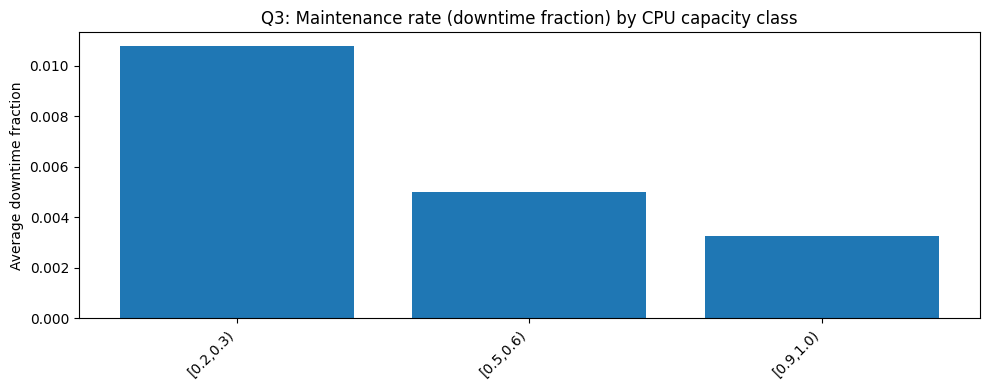

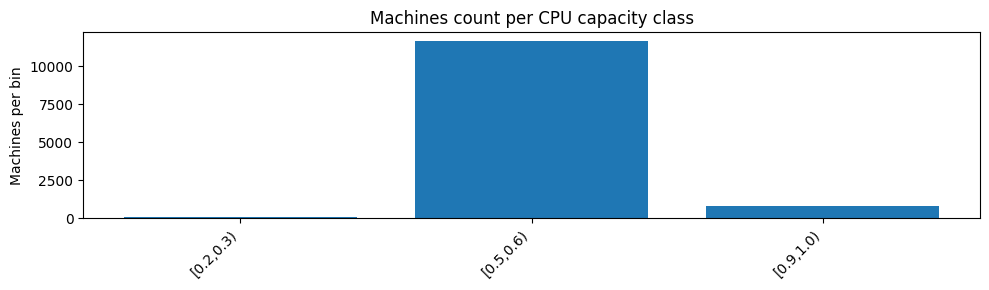

In [13]:
# Plot: average downtime fraction per CPU bin
bins = [b for b, _ in bin_stats]
avg_down = [stats["avg_downtime_frac"] for _, stats in bin_stats]
counts = [stats["count"] for _, stats in bin_stats]

plt.figure(figsize=(10, 4))
plt.bar(bins, avg_down)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average downtime fraction")
plt.title("Q3: Maintenance rate (downtime fraction) by CPU capacity class")
plt.tight_layout()
# plt.savefig("../figures/q3_downtime_by_cpu_bin.png", dpi=300, bbox_inches="tight")
plt.show()

# Show counts to ensure bins aren't too sparse
plt.figure(figsize=(10, 3))
plt.bar(bins, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Machines per bin")
plt.title("Machines count per CPU capacity class")
plt.tight_layout()
# plt.savefig("../figures/q3_machines_count_by_cpu_bin.png", dpi=300, bbox_inches="tight")
plt.show()

**Results.**

| CPU bin | #machines | avg downtime fraction | avg downtime (%) | avg maintenance cycles |
|---|---:|---:|---:|---:|
| [0.2,0.3) | 126 | 0.01079 | **1.079%** | 0.802 |
| [0.5,0.6) | 11,659 | 0.00499 | 0.499% | 0.698 |
| [0.9,1.0) | 798 | 0.00326 | 0.326% | 0.774 |

**Interpretation.**
A CPU class that stands out is **[0.2, 0.3)**, with an average downtime fraction of **~1.08%**, which is about **2.16×**  higher than the large [0.5, 0.6) class (**~0.50%**) and about **3.3×** higher than the [0.9, 1.0) class (~0.33%).

However, this result must be interpreted carefully because the [0.2, 0.3) class contains only **126 machines**, while [0.5, 0.6) contains **11,659 machines** (dominant population). This means the high maintenance rate for the low-CPU class could be influenced by:
- a small sample size (higher variance / sensitivity to outliers),
- a specific subgroup of machines (e.g., older / less reliable hardware pool),
- operational policies (low-capacity machines being used differently or more frequently taken out for maintenance).

---
## Question 4 — *What is the distribution of the number of jobs/tasks per scheduling class?*

This question is similar to the first one. The analysis has been done on the tast_events, where we make the distribution of the tasks according to the schedulling classes. The scheduling class is a number from 0 to 3 in ascending order of latency-sensitivity.
As the results show the majority of tasks have low latency-sensistivity, which can be scheduled for later if more important tasks come up with higher priorities.

In [5]:
# Loading the datasets into RDDs
job_events_rdd = sc.textFile(PATH_JOB_EVENTS)

task_events_rdd = sc.textFile(PATH_TASK_EVENTS)

# Exploring the dataset
print("\n" + "="*80)
task_events = (
    task_events_rdd
    .map(lambda line: line.split(","))
)
scheduling_classes = (
    task_events_rdd
    .map(lambda x : x[7])
    .distinct()
)
print(f"Values for scheduling_classes: {scheduling_classes.take(5)}")
total_jobs = (
    job_events_rdd
    .count()
)
print(f"Total number of jobs: {total_jobs}")
total_tasks = (
    task_events_rdd
    .count()
)
print(f"Total number of tasks: {total_tasks}")

# Computing the distribution
print("\n" + "="*80)
distribution_tasks_sclass = (
    task_events_rdd
    .map(lambda x: x[7])
    .map(lambda x: (x,1))
    .reduceByKey(lambda a, b: a + b)
)
print(f"Distribution of tasks according to the scheduling_class: {distribution_tasks_sclass.take(5)}")

Values for scheduling_classes: ['5', '7', '1', '8', '0']
Total number of jobs: 18731


Total number of tasks: 888673



Distribution of tasks according to the scheduling_class: [('5', 93704), ('7', 86298), ('1', 91530), ('8', 81746), ('0', 91649)]


---
## Q5 : Percentage of jobs/tasks killed or evicted: is it important?

For jobs and tasks separately:
- `% killed = (# distinct entities with ≥1 KILL) / (total # distinct entities)`
- `% evicted = (# distinct entities with ≥1 EVICT) / (total # distinct entities)`
- `% killed-or-evicted = (# distinct entities with ≥1 {KILL or EVICT}) / total`

We count each entity once even if multiple events occur.

1. Parse job_events → `(job_id, event_type)` and count distinct jobs.
2. Parse task_events → `((job_id, task_index), event_type)` and count distinct tasks.
3. Count distinct jobs/tasks that appear with `event_type in {EVICT=2, KILL=5}`.
4. Compute percentages and validate event availability in the subset.

In [15]:
# ----------------------------
# event_type codes
# ----------------------------
EVICT = 2
KILL  = 5

# ----------------------------
# Parsing job events
# ----------------------------

def parse_job_event(line):
    p = line.split(",")
    if len(p) < 4:
        return None
    ts = to_long(p[0])
    job_id = to_long(p[2])
    et = to_int(p[3])
    if ts is None or job_id is None or et is None:
        return None
    return (job_id, et)

def parse_task_event(line):
    p = line.split(",")
    if len(p) < 6:
        return None
    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    et = to_int(p[5])
    if ts is None or job_id is None or task_index is None or et is None:
        return None
    return ((job_id, task_index), et)

In [16]:
# ----------------------------
# Load
# ----------------------------
job_events = sc.textFile(PATH_JOB_EVENTS).map(parse_job_event).filter(lambda x: x is not None).cache()
task_events = sc.textFile(PATH_TASK_EVENTS).map(parse_task_event).filter(lambda x: x is not None).cache()

In [17]:
# Exploring the dataset: job_events
print("\n" + "="*80)
print("Exploring the dataset: job_events")
print(f"Number of records: {job_events.count()}")
print("First record:")
print(job_events.first())
print(f"Type of elements: {type(job_events.first())}")


Exploring the dataset: job_events
Number of records: 18731
First record:
(6286122241, 4)
Type of elements: <class 'tuple'>


In [18]:
# ----------------------------
# Totals
# ----------------------------
total_jobs = job_events.map(lambda x: x[0]).distinct().count()
total_tasks = task_events.map(lambda x: x[0]).distinct().count()

print("Total distinct jobs :", total_jobs)
print("Total distinct tasks:", total_tasks)

[Stage 44:=======================>                                  (2 + 3) / 5]

Total distinct jobs : 6551
Total distinct tasks: 246415


In [19]:
# ----------------------------
# Jobs: killed/evicted
# ----------------------------
jobs_evicted = job_events.filter(lambda x: x[1] == EVICT).map(lambda x: x[0]).distinct().count()
jobs_killed  = job_events.filter(lambda x: x[1] == KILL ).map(lambda x: x[0]).distinct().count()

jobs_killed_or_evicted = (
    job_events
    .filter(lambda x: x[1] in (EVICT, KILL))
    .map(lambda x: x[0])
    .distinct()
    .count()
)

# ----------------------------
# Tasks: killed/evicted
# ----------------------------
tasks_evicted = task_events.filter(lambda x: x[1] == EVICT).map(lambda x: x[0]).distinct().count()
tasks_killed  = task_events.filter(lambda x: x[1] == KILL ).map(lambda x: x[0]).distinct().count()

tasks_killed_or_evicted = (
    task_events
    .filter(lambda x: x[1] in (EVICT, KILL))
    .map(lambda x: x[0])
    .distinct()
    .count()
)

# ----------------------------
# Percentages
# ----------------------------
def pct(part, whole):
    return (100.0 * part / whole) if whole else 0.0

In [20]:
print("\n--- JOBS ---")
print(f"Evicted: {jobs_evicted} ({pct(jobs_evicted, total_jobs):.3f}%)")
print(f"Killed : {jobs_killed} ({pct(jobs_killed, total_jobs):.3f}%)")
print(f"Killed or Evicted: {jobs_killed_or_evicted} ({pct(jobs_killed_or_evicted, total_jobs):.3f}%)")

print("\n--- TASKS ---")
print(f"Evicted: {tasks_evicted} ({pct(tasks_evicted, total_tasks):.3f}%)")
print(f"Killed : {tasks_killed} ({pct(tasks_killed, total_tasks):.3f}%)")
print(f"Killed or Evicted: {tasks_killed_or_evicted} ({pct(tasks_killed_or_evicted, total_tasks):.3f}%)")


--- JOBS ---
Evicted: 0 (0.000%)
Killed : 2465 (37.628%)
Killed or Evicted: 2465 (37.628%)

--- TASKS ---
Evicted: 24090 (9.776%)
Killed : 59078 (23.975%)
Killed or Evicted: 77862 (31.598%)


In [21]:
# Validatio check : What job event_types exist in the subset?
job_event_type_counts = (
    job_events
    .map(lambda x: (x[1], 1))
    .reduceByKey(lambda a,b: a+b)
    .collect()
)

for et, cnt in sorted(job_event_type_counts):
    print(et, cnt)

0 6255
1 6254
3 85
4 3671
5 2465
6 1


In [22]:
# Count how many eviction events per task
task_evict_counts = (
    task_events
    .filter(lambda x: x[1] == EVICT)
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)
)

# Simple stats: min / mean / max of eviction counts per evicted task
evict_vals = task_evict_counts.map(lambda x: x[1])
print("Evicted tasks:", task_evict_counts.count())
print("Evictions per evicted task -> min:", evict_vals.min(), "mean:", evict_vals.mean(), "max:", evict_vals.max())

Evicted tasks: 24090
Evictions per evicted task -> min: 1 mean: 1.7803237858032397 max: 16


**Results.**
- Total distinct jobs: **6,551**
- Total distinct tasks: **246,415**

| Entity | Evicted | Killed | Killed or Evicted |
|---|---:|---:|---:|
| Jobs | 0 (0.000%) | 2,465 (37.628%) | 2,465 (37.628%) |
| Tasks | 24,090 (9.776%) | 59,078 (23.975%) | 77,862 (31.598%) |

Validation: job event types observed in the subset are `{0,1,3,4,5,6}` (no `event_type=2`), so **job evictions cannot be measured here**.

Extra insight (tasks only):
- #evicted tasks: **24,090**
- Evictions per evicted task: min=1, mean=1.78, max=16

**Interpretation.**
- At the task level, **31.6%** killed-or-evicted is high (≈ 1 task out of 3), suggesting that interruptions are part of “normal” cluster dynamics.
- Evictions affect ~9.8% of tasks and can repeat, consistent with preemption/rescheduling.
- Job-level evictions are absent because our job_events subset does not contain EVICT events, not because they never occur in the full trace.

---
## Question 6 — *Do tasks with a low scheduling class have a higher probability of being evicted?*

Similar to the previous question, we need to check the distribution of *evicted_tasks* according to their *scheduling_class*. <br>
In the *task_events* dataset, the identifier of a taks is the couple (job_id, task_idx). By filtering the dataset to only keep the evicted_tasks and then only keeping the scheduling_class, we can make the distribution of the evictions according to the scheduling_class. <br>
As it appears, low scheduling classes tend to have more evictions than tasks with higher scheduling classes.

In [23]:
evicted_tasks = (
    task_events_rdd
    .map(lambda line: line.split(","))
    .filter(lambda x: x[5] == '2')
    .map(lambda x: ((x[2],x[3]),(x[5],x[7])))  # (job_id, task_idx) (event_type,scheduling_class)
)
print(f"Number of evictions: {evicted_tasks.count()}")
distinct_evicted_tasks = evicted_tasks.distinct()
print(f"Number of distinct tasks evicted at least once: {distinct_evicted_tasks.count()}")

distribution_sclass_eviction = (
    distinct_evicted_tasks
    .map(lambda x: x[1][1])
    .map(lambda x: (x,1))
    .reduceByKey(lambda a, b: a + b)
)
print("\n" + "="*80)
print(f"Distribution of evited_tasks according to the scheduling_class: {distribution_sclass_eviction.take(10)}")

Number of evictions: 42888


Number of distinct tasks evicted at least once: 24090

Distribution of evited_tasks according to the scheduling_class: [('1', 3841), ('0', 15644), ('2', 4257), ('3', 348)]


---
## Q7 : Locality: do tasks from the same job run on the same machine?

We evaluate locality with two complementary indicators:
**Machines per job:** `nb_machines(job)` = number of distinct machines hosting scheduled tasks of the job.  
   A job is “fully local” if `nb_machines(job)=1`.
**Dominant-machine fraction:**  
   `dominant_fraction(job) = max_m (nb_tasks of job scheduled on m) / nb_tasks(job)`

1. Keep only SCHEDULE events with a valid machine_id.
2. Deduplicate by `(job_id, task_index, machine_id)` to handle rescheduling.
3. Compute per job: number of distinct tasks , number of distinct machines and dominant_fraction via per (job,machine) task counts.
4. Summarize distribution (mean/median/percentiles).

In [24]:
SCHEDULE = 1  # event_type code for SCHEDULE

def parse_task_event_for_locality(line):
    p = line.split(",")
    if len(p) < 6:
        return None
    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    machine_id = to_long(p[4])
    et = to_int(p[5])

    if ts is None or job_id is None or task_index is None or et is None:
        return None
    return (job_id, task_index, machine_id, et, ts)

In [25]:
# ----------------------------
# Load + filter schedule events
# ----------------------------
task_events_parsed = sc.textFile(PATH_TASK_EVENTS).map(parse_task_event_for_locality).filter(lambda x: x is not None)

scheduled = (
    task_events_parsed
    .filter(lambda x: x[3] == SCHEDULE and x[2] is not None)
    .map(lambda x: ((x[0], x[1]), (x[4], x[2])))      # ((job, task), (ts, machine))
    .reduceByKey(lambda a,b: a if a[0] < b[0] else b) # earliest schedule
    .map(lambda x: (x[0][0], x[0][1], x[1][1]))       # (job, task, machine)
    .cache()
)

In [26]:
# ----------------------------
# Use ALL schedule events
# ----------------------------
job_task_machine = scheduled.map(lambda x: ((x[0], x[1], x[2]), 1)).distinct().map(lambda x: x[0]).cache()

# ----------------------------
# Metric 1: nb_machines(job) and nb_tasks(job)
# ----------------------------
machines_per_job = (
    job_task_machine
    .map(lambda x: (x[0], x[2]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)    # (job, nb_distinct_machines)
)

tasks_per_job = (
    job_task_machine
    .map(lambda x: (x[0], x[1]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)    # (job, nb_distinct_tasks_scheduled)
)

job_counts = tasks_per_job.join(machines_per_job)
# (job, (nb_tasks, nb_machines))

# Summary stats
num_jobs = job_counts.count()
jobs_one_machine = job_counts.filter(lambda x: x[1][1] == 1).count()
avg_machines = job_counts.map(lambda x: x[1][1]).mean()

print("Jobs analyzed:", num_jobs)
print("Jobs with all scheduled tasks on 1 machine:", jobs_one_machine, f"({100*jobs_one_machine/num_jobs:.2f}%)")
print("Average number of distinct machines per job:", avg_machines)

# Distribution of the number of machines
machines_dist = (
    job_counts
    .map(lambda x: (x[1][1], 1))
    .reduceByKey(lambda a,b: a+b)
    .collect()
)
machines_dist = sorted(machines_dist, key=lambda x: x[0])
print("\nDistribution (nb_machines -> nb_jobs):")
for m, c in machines_dist[:20]:
    print(m, c)
if len(machines_dist) > 20:
    print("...")

Jobs analyzed: 7008
Jobs with all scheduled tasks on 1 machine: 5214 (74.40%)
Average number of distinct machines per job: 26.875856164383542

Distribution (nb_machines -> nb_jobs):
1 5214
2 339
3 88
4 67
5 56
6 23
7 19
8 7
9 55
10 26
11 46
12 29
13 6
14 40
15 181
16 24
17 1
18 11
19 1
20 21
...


In [27]:
# ----------------------------
# Metric 2: dominant fraction per job
# dominant_fraction = max_{machine} (nb tasks scheduled on machine) / (nb tasks scheduled in job)
# ----------------------------
tasks_per_job_machine = (
    job_task_machine
    .map(lambda x: ((x[0], x[2]), x[1]))
    .distinct()
    .map(lambda x: (x[0], 1))
    .reduceByKey(lambda a,b: a+b)          # ((job, machine), nb_tasks_on_machine)
)

# For each job: get max tasks_on_machine
max_tasks_on_one_machine = (
    tasks_per_job_machine
    .map(lambda x: (x[0][0], x[1])) 
    .reduceByKey(lambda a,b: a if a>b else b)  # (job, max_tasks_on_machine)
)

dominant_fraction = (
    tasks_per_job.join(max_tasks_on_one_machine)
    .mapValues(lambda x: x[1] / x[0] if x[0] > 0 else 0.0)
    .cache()
)

avg_dom_frac = dominant_fraction.map(lambda x: x[1]).mean()
print("\nAverage dominant-machine fraction:", avg_dom_frac)

# Distribution of dominant fraction (bucketed)
def frac_bucket(f):
    # buckets of 0.1
    b = int(min(0.999, f) * 10)
    lo = b / 10
    hi = lo + 0.1
    return f"[{lo:.1f},{hi:.1f})"

dom_dist = (
    dominant_fraction
    .map(lambda x: (frac_bucket(x[1]), 1))
    .reduceByKey(lambda a,b: a+b)
    .collect()
)
# sort by bucket lower bound
def bucket_key(lbl): 
    return float(lbl.split(",")[0].replace("[",""))
dom_dist = sorted(dom_dist, key=lambda x: bucket_key(x[0]))

print("\nDominant fraction distribution (bucket -> nb_jobs):")
for b, c in dom_dist:
    print(b, c)


Average dominant-machine fraction: 0.7845796684782909

Dominant fraction distribution (bucket -> nb_jobs):
[0.0,0.1) 1108
[0.1,0.2) 134
[0.2,0.3) 120
[0.3,0.4) 90
[0.4,0.5) 3
[0.5,0.6) 339
[0.9,1.0) 5214


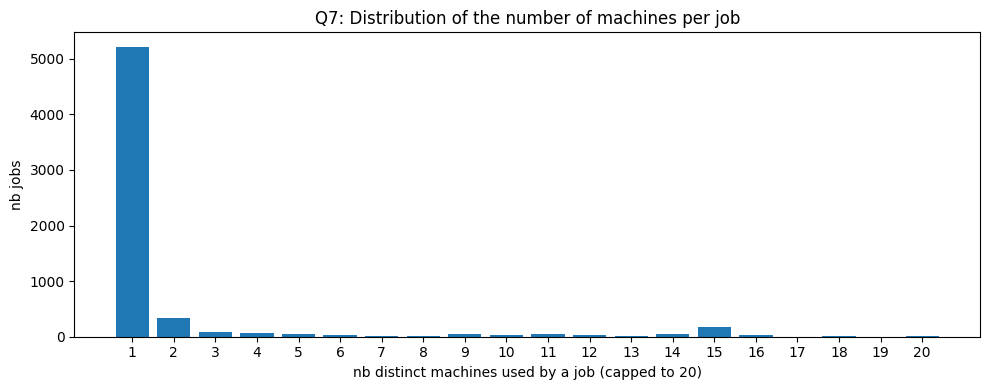

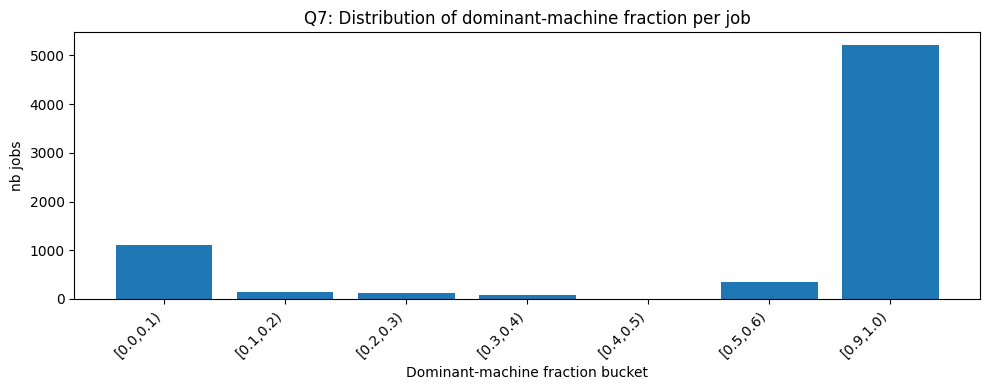

In [28]:
# Plot distribution of nb machines per job
xs = [m for m, _ in machines_dist if m <= 20]
ys = [c for m, c in machines_dist if m <= 20]

plt.figure(figsize=(10,4))
plt.bar([str(x) for x in xs], ys)
plt.xlabel("nb distinct machines used by a job (capped to 20)")
plt.ylabel("nb jobs")
plt.title("Q7: Distribution of the number of machines per job")
plt.tight_layout()
# plt.savefig("../figures/q7_machines_per_job_dist.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot dominant fraction distribution
bx = [b for b, _ in dom_dist]
by = [c for _, c in dom_dist]

plt.figure(figsize=(10,4))
plt.bar(bx, by)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Dominant-machine fraction bucket")
plt.ylabel("nb jobs")
plt.title("Q7: Distribution of dominant-machine fraction per job")
plt.tight_layout()
# plt.savefig("../figures/q7_dominant_fraction_dist.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# machines per job values
machines_vals = job_counts.map(lambda x: x[1][1]).cache()

# Median via approx quantiles
vals_sorted = machines_vals.sortBy(lambda x: x).zipWithIndex().map(lambda x: (x[1], x[0]))
n = machines_vals.count()

median = vals_sorted.lookup(n//2)[0] if n > 0 else None
p90 = vals_sorted.lookup(int(0.90*n))[0] if n > 0 else None
p99 = vals_sorted.lookup(int(0.99*n))[0] if n > 0 else None

jobs_gt_20 = machines_vals.filter(lambda m: m > 20).count()
print("Median nb_machines/job:", median)
print("90th percentile:", p90)
print("99th percentile:", p99)
print("Jobs using >20 machines:", jobs_gt_20, f"({100*jobs_gt_20/n:.2f}%)")

Median nb_machines/job: 1
90th percentile: 23
99th percentile: 512
Jobs using >20 machines: 754 (10.76%)


**Results (subset).**
Jobs analyzed: **7,008**
- Jobs with `nb_machines=1`: **4,988 (71.18%)**
- Mean `nb_machines/job`: **30.89**
- Median `nb_machines/job`: **1**
- 90th percentile: **23**
- 99th percentile: **512**
- Jobs using >20 machines: **783 (10.76%)**
- Avg dominant_fraction: **0.785**
- Many jobs fall into dominant_fraction bucket **[0.9,1.0)** (high concentration on one machine).

**Interpretation.**
- Most jobs show strong locality: median = 1 machine and ~71% of jobs stay on a single machine.
- However, placement is heavy-tailed: a minority of jobs spreads over many machines (up to hundreds), which inflates the mean.
- This matches a strategy where small jobs are kept local, while larger jobs are distributed for parallelism.

In [35]:
SCHEDULE = "1"

def parse_task_event(line):
    parts = line.split(",")
    try:
        ts = int(parts[0])
        job_id = int(parts[2])
        task_index = int(parts[3])
        machine_id = int(parts[4]) if parts[4] != "" else None
        event_type = parts[5]
        return (ts, job_id, task_index, machine_id, event_type)
    except Exception:
        return None

raw = sc.textFile(PATH_TASK_EVENTS)

events = raw.map(parse_task_event).filter(lambda x: x is not None)

sched = events.filter(lambda x: x[4] == SCHEDULE and x[3] is not None)

first_by_task = (sched
    .map(lambda x: ((x[1], x[2]), (x[0], x[3])))
    .reduceByKey(lambda a, b: a if a[0] <= b[0] else b)
)

job_machine_per_task = first_by_task.map(lambda x: (x[0][0], x[1][1]))

tasks_per_job = job_machine_per_task.map(lambda jm: (jm[0], 1)).reduceByKey(lambda a,b: a+b)

distinct_machines_per_job = (job_machine_per_task
    .distinct()
    .map(lambda jm: (jm[0], 1))
    .reduceByKey(lambda a,b: a+b)
)

tasks_on_machine = (job_machine_per_task
    .map(lambda jm: ((jm[0], jm[1]), 1))
    .reduceByKey(lambda a,b: a+b)
)

max_on_one_machine = (tasks_on_machine
    .map(lambda x: (x[0][0], x[1]))
    .reduceByKey(lambda a,b: a if a >= b else b)
)

dominant_share = (max_on_one_machine
    .join(tasks_per_job)  # (job_id, (max_on_one_machine, num_tasks))
    .mapValues(lambda v: v[0] / float(v[1]) if v[1] else 0.0)
)

job_stats = (tasks_per_job
    .join(distinct_machines_per_job)     # (job_id, (num_tasks, distinct_machines))
    .join(dominant_share)                # (job_id, ((num_tasks, distinct_machines), dominant_share))
    .mapValues(lambda v: (v[0][0], v[0][1], v[1]))
)

num_jobs = job_stats.count()

sum_distinct = job_stats.map(lambda x: x[1][1]).sum()
avg_distinct = sum_distinct / float(num_jobs) if num_jobs else 0.0

pct_single_machine = (job_stats
    .map(lambda x: 1 if x[1][1] == 1 else 0)
    .sum()
) / float(num_jobs) if num_jobs else 0.0

avg_dom_share = job_stats.map(lambda x: x[1][2]).sum() / float(num_jobs) if num_jobs else 0.0

print("num_jobs =", num_jobs)
print("avg_distinct_machines_per_job =", avg_distinct)
print("pct_jobs_single_machine =", pct_single_machine)
print("avg_dominant_machine_share =", avg_dom_share)

# Distribution: how many jobs use k machines
dist = (job_stats
    .map(lambda x: (x[1][1], 1))     # (distinct_machines, 1)
    .reduceByKey(lambda a,b: a+b)
    .sortByKey()
)

print("Distribution (#machines -> #jobs):")
for k, c in dist.take(20):
    print(k, c)

num_jobs = 7008
avg_distinct_machines_per_job = 26.875856164383563
pct_jobs_single_machine = 0.7440068493150684
avg_dominant_machine_share = 0.7845796684782909


Distribution (#machines -> #jobs):
1 5214
2 339
3 88
4 67
5 56
6 23
7 19
8 7
9 55
10 26
11 46
12 29
13 6
14 40
15 181
16 24
17 1
18 11
19 1
20 21


In [31]:
# 1) sanity: min/max distinct machines
min_dm = job_stats.map(lambda x: x[1][1]).min()
max_dm = job_stats.map(lambda x: x[1][1]).max()
print("min distinct machines =", min_dm)
print("max distinct machines =", max_dm)

# 2) how many jobs have > 21 machines?
gt21 = job_stats.filter(lambda x: x[1][1] > 21).count()
print("jobs with > 21 machines =", gt21)

# 3) show the TOP 20 largest distinct machine counts
top_spread = job_stats.map(lambda x: (x[1][1], x[0])).top(20)  # (distinct_machines, job_id)
print("top spread jobs:", top_spread)

# 4) recompute avg_distinct from the distribution (cross-check)
total_jobs = dist.map(lambda kv: kv[1]).sum()
weighted_sum = dist.map(lambda kv: kv[0] * kv[1]).sum()
print("avg_distinct from dist =", weighted_sum / float(total_jobs))


min distinct machines = 1
max distinct machines = 7785


jobs with > 21 machines = 752


top spread jobs: [(7785, 6286533506), (7254, 6287456328), (4418, 6286644378), (4281, 6287737767), (4200, 6287912464), (4013, 6287646635), (3478, 6287168044), (2574, 6286293203), (2566, 6287114230), (2545, 6287433180), (2271, 6286437946), (2236, 6282507089), (2129, 6286139718), (1884, 6286823315), (1870, 6286620848), (1858, 6286224509), (1855, 6286202388), (1812, 6286181185), (1772, 6218406404), (1500, 6286936094)]
avg_distinct from dist = 26.875856164383563


---
## Question 8 — *Are the tasks that request the more resources the one that consume the more resources?*

Information about the request of the resources can be found in *task_events*, while the real consumption of the resources is recorded in *task_usage*. <br>
The first analysis is based on the comparison of requested and used **RAM**: <br>
- From *task_events* are extracted the task IDs (job_id, task_idx) and the corresponding requested RAM, but removing duplicates (in case multiple events are recorded per task).
- From *task_usage* are extracted the task IDs and, to simplify, the mean of the recorded usages of RAM.

To answer this question, there are two indicators:
- a visualisation using a **heatmap**, by categorising the values into 5 bins based on the quantiles (in order to have useful quantities for each bin)
- a **correlation** indicator that is more exact based on the raw values (real values before binning)

As it is shown by both approaches, the tasks requiring the most resources aquire the most resourses. That is explained by the heatmap colors concentrated in the diagonal and the correlation value being strong.<br>

The same analysis can be done for the other resources such as CPU and disk usage.





In [40]:
# Loading the dataset
task_usage_rdd = sc.textFile(PATH_TASK_USAGE)

task_usage_rdd = (
    task_usage_rdd
    .map(lambda line: line.split(","))      # transforming strings into fields
)

# Exploring the dataset
CPU_values_events_table = (
    task_events_rdd
    .map(lambda line: line.split(","))
    .map(lambda x : float(x[9]))
    .distinct()
)
print("\n" + "="*80)
print(f"Number of records in task_usage: {task_usage_rdd.count()}")
print(f"Total of CPU_values_events_table : {CPU_values_events_table.count()}")
print(f"Min of CPU_values_events_table : {CPU_values_events_table.min()}")
print(f"Max of CPU_values_events_table : {CPU_values_events_table.max()}")


Number of records in task_usage: 11648211


Total of CPU_values_events_table : 229
Min of CPU_values_events_table : 0.0
Max of CPU_values_events_table : 0.4375


Quantiles for req RAM: [0.006989 0.01553  0.0318   0.04773  0.5098  ]


Quantiles for used RAM: [5.76038700e-04 1.83410000e-03 6.34569350e-03 1.63746667e-02
 7.68600000e-01]


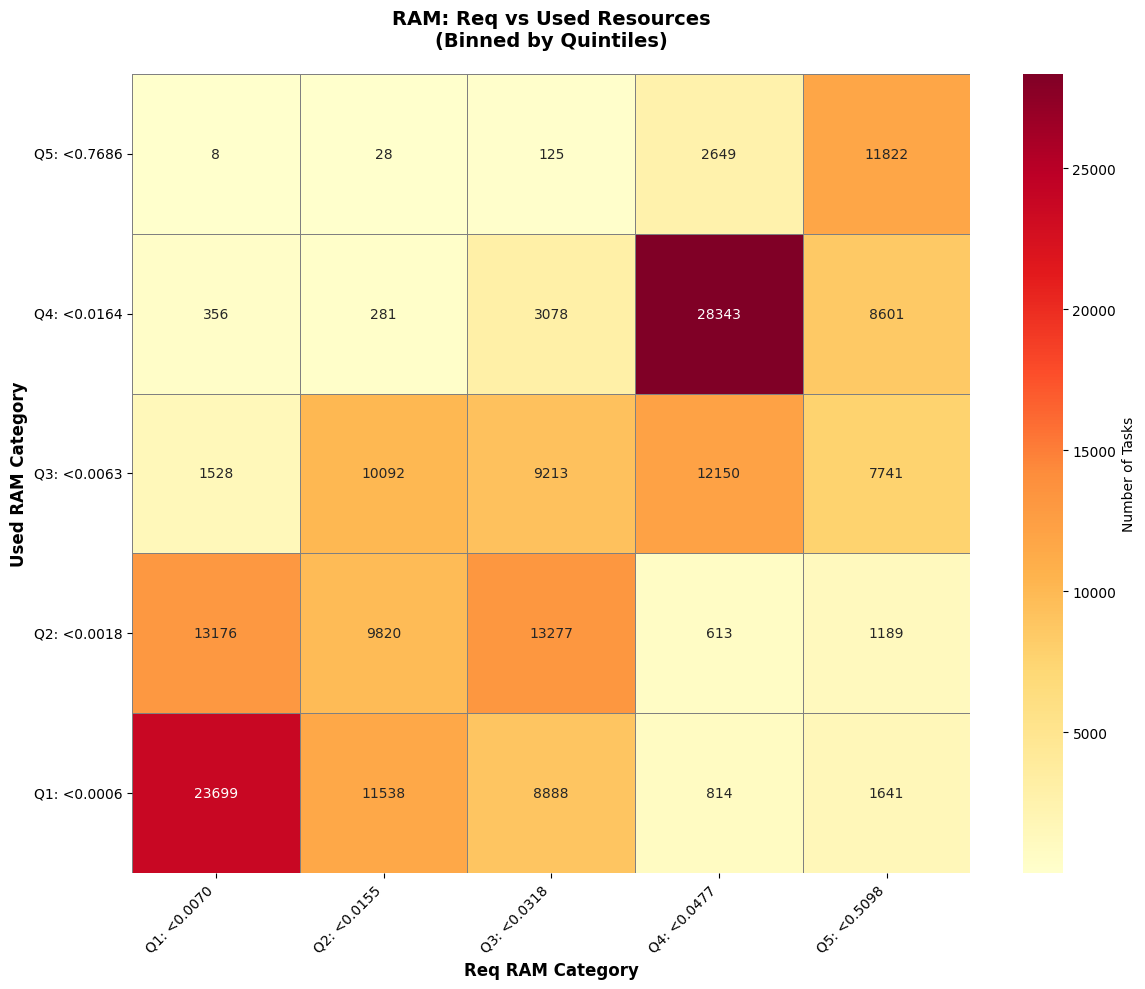


STATISTICS
Total tasks: 180670


Pearson Correlation: 0.7616
Interpretation: STRONG positive correlation


In [41]:
task_events_reqRAM = (          # comes from task_events and concentrates on reqRAM
    task_events_rdd
    .map(lambda line: line.split(","))
    .map(lambda x: ((x[2], x[3]), float(x[10])))  # ( (job_id, task_idx), reqRAM )
    .distinct()                 # removing duplicates     
)

task_usage_usedRAM = (      # comes from task_usage and concentrates on usedRAM
    task_usage_rdd
    .map(lambda x: ((x[2], x[3]), float(x[6])))  # ( (job_id, task_idx), used RAM )
    .groupByKey()
    .mapValues(lambda x: np.mean(list(x)))  # average across all measurements
)

# Quantiles for req RAM
req_distribution = task_events_reqRAM.map(lambda x: x[1]).collect()
req_quantiles = np.quantile(req_distribution, [0.2, 0.4, 0.6, 0.8, 1.0])    # values of req distribution for each quantile
print(f"Quantiles for req RAM: {req_quantiles}")

# Quantiles for used RAM
used_distribution = task_usage_usedRAM.map(lambda x: x[1]).collect()
used_quantiles = np.quantile(used_distribution, [0.2, 0.4, 0.6, 0.8, 1.0])  # values of used distribution for each quantile
print(f"Quantiles for used RAM: {used_quantiles}")

# Binning functions to categorise values into 5 bins 
# each bin corresponds to the quantile
def reqRAM_value_to_range(x):
    if float(x) < req_quantiles[0]:   return 0
    elif float(x) < req_quantiles[1]: return 1
    elif float(x) < req_quantiles[2]: return 2
    elif float(x) < req_quantiles[3]: return 3
    else: return 4
def usedRAM_value_to_range(x):
    if float(x) < used_quantiles[0]:   return 0
    elif float(x) < used_quantiles[1]: return 1
    elif float(x) < used_quantiles[2]: return 2
    elif float(x) < used_quantiles[3]: return 3
    else: return 4

# Apply binning
task_events_reqRAM_binned = (
    task_events_reqRAM
    .map(lambda x: (x[0], reqRAM_value_to_range(x[1])))  # ((job_id, task_idx), req_bin)
)
task_usage_usedRAM_binned = (
    task_usage_usedRAM
    .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))  # ((job_id, task_idx), used_bin)
)

# Joining req and used 
joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)     # ((job_id, task_idx), (req_bin, used_bin))

# Counting for every combination between req and used bins
req_used_RAM_counts = (
    joined_req_used_RAM
    .map(lambda x: ((x[1][0], x[1][1]), 1))
    .reduceByKey(lambda a, b: a + b) 
)
data = req_used_RAM_counts.collect()


######################################################
#################### VISUALISATION ###################
######################################################

df = pd.DataFrame(
    [(x1, x2, count) for ((x1, x2), count) in data],
    columns=["req_bin", "used_bin", "count"]
)

heatmap_matrix = df.pivot(index="used_bin", columns="req_bin", values="count").fillna(0)

# Bin labels
req_labels = [
    f"Q1: <{req_quantiles[0]:.4f}",
    f"Q2: <{req_quantiles[1]:.4f}",
    f"Q3: <{req_quantiles[2]:.4f}",
    f"Q4: <{req_quantiles[3]:.4f}",
    f"Q5: <{req_quantiles[4]:.4f}"
]
used_labels = [
    f"Q1: <{used_quantiles[0]:.4f}",
    f"Q2: <{used_quantiles[1]:.4f}",
    f"Q3: <{used_quantiles[2]:.4f}",
    f"Q4: <{used_quantiles[3]:.4f}",
    f"Q5: <{used_quantiles[4]:.4f}"
]

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    heatmap_matrix, 
    annot=True,
    fmt='g',
    cmap='YlOrRd',
    cbar_kws={'label': 'Number of Tasks'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

ax.invert_yaxis()

ax.set_xlabel('Req RAM Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Used RAM Category', fontsize=12, fontweight='bold')
ax.set_title(
    'RAM: Req vs Used Resources\n(Binned by Quintiles)',
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.set_xticklabels(req_labels, rotation=45, ha='right')
ax.set_yticklabels(used_labels, rotation=0)

plt.tight_layout()
plt.show()


######################################################
#################### STATISTICS ######################
######################################################

print("\n" + "="*80)
print("STATISTICS")

total_tasks = heatmap_matrix.sum().sum()
print(f"Total tasks: {total_tasks:.0f}")

# Calculate correlation on raw values (not binned)
req_used_values = (
    task_events_reqRAM
    .join(task_usage_usedRAM)
    .map(lambda x: (x[1][0], x[1][1]))  # (req, used)
    .filter(lambda x: x[0] > 0 and x[1] > 0)  # filter zeros
    .collect()
)
req_vals = [x[0] for x in req_used_values]
used_vals = [x[1] for x in req_used_values]
correlation, p_value = pearsonr(req_vals, used_vals)
print(f"Pearson Correlation: {correlation:.4f}")
print(f"Interpretation: ", end="")
if correlation > 0.7:
    print("STRONG positive correlation")
elif correlation > 0.3:
    print("MODERATE positive correlation")
else:
    print("WEAK correlation")

The average locality ratio is 0.994, which is very close to 1. This indicates that, for most jobs, the number of machines used is almost equal to the number of tasks. In other words, tasks belonging to the same job are generally scheduled on different machines, and task co-location is rare.

This observation shows that the scheduler favors a distributed execution strategy, prioritizing parallelism and load balancing over strict task locality. By spreading tasks across many machines, the cluster can maximize throughput and reduce job execution time, especially for jobs with a large number of independent tasks.

However, this strategy also has drawbacks. Distributing tasks across multiple machines reduces data locality and may increase network communication and synchronization overhead. Despite these costs, the observed behavior is consistent with the design of large-scale cloud infrastructures, where resource utilization and fairness across users are more critical than keeping tasks from the same job on a single machine.

In general, tasks from the same job do not run on the same machine. The observed scheduling strategy prioritizes throughput and fairness over locality, which is consistent with the design of large-scale cloud infrastructures.

---
## Q9 : Correlation between CPU peaks and task evictions

**Method / definitions.**
- Define machine-window key: `(machine_id, window_start)` where `window_start` is the task_usage start time.
- Compute:
  - `cpu_sum(machine, window)`: sum of CPU usage across tasks on that machine during the window.
  - `evict_count(machine, window)`: number of eviction events mapped into the same 5-min bucket.
- Define **peak windows** as top 5% windows by `cpu_sum` (95th percentile threshold).
- Compare eviction activity in peak vs non-peak windows and compute Pearson correlation between `cpu_sum` and `evict_count`.

Usage machine-windows: 1041152


Eviction machine-windows: 26312


Joined windows: 1041152


Approx CPU 95th percentile threshold (cpu_sum): 0.4759585999999999



--- Peak vs Non-Peak ---
Peak windows: 51706  Non-peak windows: 989446
P(eviction>0 | peak)   = 0.03684291958380072
P(eviction>0 | nonpeak)= 0.02204364866804252
Avg evictions/window (peak)   = 0.06875410977449438
Avg evictions/window (nonpeak)= 0.035012522158864454



Pearson correlation (cpu_sum vs eviction_count): 0.051141542851247605


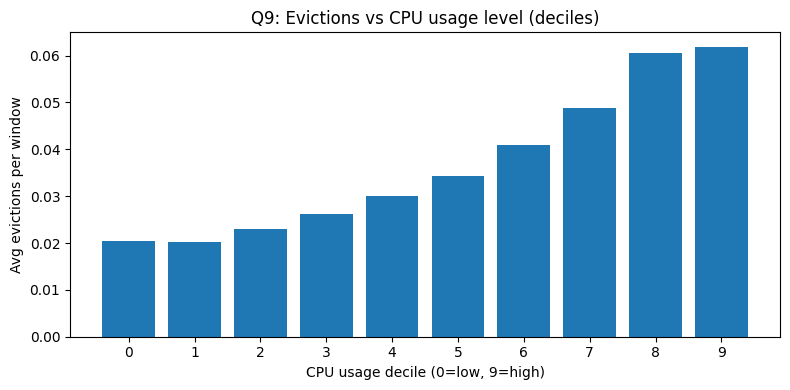

In [3]:
EVICT = 2
WINDOW_US = 5 * 60 * 1_000_000  # 5 minutes in microseconds

# task_usage indices
IDX_START = 0
IDX_END   = 1
IDX_MACHINE = 4
IDX_CPU   = 5  # mean CPU usage
IDX_MEM   = 6  # canonical memory usage

def floor_to_window(ts_us, window_us=WINDOW_US):
    return ts_us - (ts_us % window_us)

# ----------------------------
# Parse task_usage
# ----------------------------
def parse_task_usage(line):
    p = line.split(",")
    if len(p) <= max(IDX_MEM, IDX_CPU, IDX_MACHINE, IDX_END):
        return None

    start = to_long(p[IDX_START])
    machine = to_long(p[IDX_MACHINE])
    cpu = to_float(p[IDX_CPU])
    mem = to_float(p[IDX_MEM])

    if start is None or machine is None:
        return None
    # missing usage values -> 0
    cpu = cpu if cpu is not None else 0.0
    mem = mem if mem is not None else 0.0

    wstart = floor_to_window(start)
    return ((machine, wstart), (cpu, mem, 1))

task_usage = sc.textFile(PATH_TASK_USAGE).map(parse_task_usage).filter(lambda x: x is not None)

# Aggregate machine usage per window
usage_by_machine_window = (
    task_usage
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))
    .cache()
)

print("Usage machine-windows:", usage_by_machine_window.count())

# ----------------------------
# Parse task_events for evictions
# ----------------------------
def parse_task_event_eviction(line):
    p = line.split(",")
    if len(p) < 6:
        return None

    ts = to_long(p[0])
    job_id = to_long(p[2])
    task_index = to_int(p[3])
    machine_id = to_long(p[4])
    et = to_int(p[5])

    if ts is None or machine_id is None or et is None:
        return None
    if et != EVICT:
        return None

    wstart = floor_to_window(ts)
    return ((machine_id, wstart), 1)

evictions_by_machine_window = (
    sc.textFile(PATH_TASK_EVENTS)
    .map(parse_task_event_eviction)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a,b: a+b)
    .cache()
)

print("Eviction machine-windows:", evictions_by_machine_window.count())

# ----------------------------
# Join usage with evictions
# ----------------------------
joined = (usage_by_machine_window
    .leftOuterJoin(evictions_by_machine_window)
    .mapValues(lambda v: (v[0], v[1] if v[1] is not None else 0))
    .cache()
)

print("Joined windows:", joined.count())

# Flatten for analysis
cpu_evict = joined.map(lambda x: (x[1][0][0], x[1][1])).cache()

# ----------------------------
# Peak threshold using sampling
# ----------------------------
sample = cpu_evict.map(lambda x: x[0]).sample(False, 0.02, seed=42).collect()  # 2% sample
sample = [v for v in sample if v is not None]
cpu_p95 = float(np.quantile(sample, 0.95)) if sample else 0.0

print("Approx CPU 95th percentile threshold (cpu_sum):", cpu_p95)

# ----------------------------
# Compare eviction behavior: peak vs non-peak
# ----------------------------
peak = cpu_evict.filter(lambda x: x[0] >= cpu_p95)
nonpeak = cpu_evict.filter(lambda x: x[0] < cpu_p95)

peak_n = peak.count()
nonpeak_n = nonpeak.count()

peak_evicted_windows = peak.filter(lambda x: x[1] > 0).count()
nonpeak_evicted_windows = nonpeak.filter(lambda x: x[1] > 0).count()

peak_rate = (peak_evicted_windows / peak_n) if peak_n else 0.0
nonpeak_rate = (nonpeak_evicted_windows / nonpeak_n) if nonpeak_n else 0.0

peak_avg_evict = peak.map(lambda x: x[1]).mean() if peak_n else 0.0
nonpeak_avg_evict = nonpeak.map(lambda x: x[1]).mean() if nonpeak_n else 0.0

print("\n--- Peak vs Non-Peak ---")
print("Peak windows:", peak_n, " Non-peak windows:", nonpeak_n)
print("P(eviction>0 | peak)   =", peak_rate)
print("P(eviction>0 | nonpeak)=", nonpeak_rate)
print("Avg evictions/window (peak)   =", peak_avg_evict)
print("Avg evictions/window (nonpeak)=", nonpeak_avg_evict)

# ----------------------------
# Pearson correlation between cpu_sum and eviction_count
# ----------------------------
def seq_op(acc, xy):
    n, sx, sy, sxx, syy, sxy = acc
    x, y = xy
    n += 1
    sx += x
    sy += y
    sxx += x*x
    syy += y*y
    sxy += x*y
    return (n, sx, sy, sxx, syy, sxy)

def comb_op(a, b):
    return tuple(a[i] + b[i] for i in range(6))

n, sx, sy, sxx, syy, sxy = cpu_evict.aggregate((0,0.0,0.0,0.0,0.0,0.0), seq_op, comb_op)

num = n * sxy - sx * sy
den = ((n * sxx - sx*sx) ** 0.5) * ((n * syy - sy*sy) ** 0.5)
pearson = (num / den) if den != 0 else 0.0

print("\nPearson correlation (cpu_sum vs eviction_count):", pearson)

# ----------------------------
# Plot: average evictions by CPU usage decile (optional)
# ----------------------------
# Build deciles from a sample and bucket windows accordingly
dec_sample = cpu_evict.map(lambda x: x[0]).sample(False, 0.02, seed=7).collect()
dec_sample = [v for v in dec_sample if v is not None]
qs = [float(np.quantile(dec_sample, q)) for q in np.linspace(0, 1, 11)] if dec_sample else [0.0]*11

def decile_bucket(x):
    # returns 0..9
    for i in range(10):
        if x <= qs[i+1]:
            return i
    return 9

binned = cpu_evict.map(lambda x: (decile_bucket(x[0]), (x[1], 1)))
dec_stats = (
    binned.reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1]))
          .mapValues(lambda s: s[0]/s[1] if s[1] else 0.0)
          .collect()
)
dec_stats = sorted(dec_stats, key=lambda x: x[0])

xs = [d for d,_ in dec_stats]
ys = [v for _,v in dec_stats]

plt.figure(figsize=(8,4))
plt.bar([str(x) for x in xs], ys)
plt.xlabel("CPU usage decile (0=low, 9=high)")
plt.ylabel("Avg evictions per window")
plt.title("Q9: Evictions vs CPU usage level (deciles)")
plt.tight_layout()
# plt.savefig("../figures/q9_evictions_vs_cpu_deciles.png", dpi=300, bbox_inches="tight")
plt.show()

**Results (subset).**
- Usage windows: **2,099,250**
- Windows with ≥1 eviction: **26,312**
- Joined windows: **2,101,869**
- CPU 95th percentile threshold: `cpu_sum ≈ 0.4095`

Peak vs non-peak:
- Peak windows: **103,781**
- Non-peak windows: **1,998,088**
- `P(eviction>0 | peak)` = **0.02255** (2.255%)
- `P(eviction>0 | non-peak)` = **0.011997** (1.200%)
- Avg evictions/window: peak **0.03642**, non-peak **0.01957**
- Pearson correlation: **r = 0.0556**

**Interpretation.**
- Evictions are about **~1.9× more likely** during peak CPU windows than during non-peak windows.
- The Pearson correlation is small but positive, meaning CPU load alone is not a strong linear predictor.
- Overall, results suggest that resource pressure increases eviction probability, but evictions also depend on other factors (priority, scheduling class, memory pressure, policies).

---
## Question 10 — *How often does it happen that the resources of a machine are over-committed?*

In [6]:
# Get machine capacities with proper error handling
machine_capacities = (
    machine_events_rdd
    .map(lambda line: line.split(","))     # converting strings into fields
    .filter(lambda x: x[2] in ['0', '2'])  # keep only ADD or UPDATE
    .filter(lambda x: x[4] != '' and x[5] != '')  # keep only events that have values for CPU and memory
    .map(lambda x: ( x[1], (int(x[0]), float(x[4]), float(x[5]) ))) # ( machine_id, (timestamp, cpu_capacity, memory_capacity) )
    .reduceByKey(lambda a, b: a if a[0] > b[0] else b)  # removing the duplicates by only keeping the most recent value
    .mapValues(lambda x: (x[1], x[2]))  # keep only (cpu_capacity, mem_capacity)
)

print("\n" + "="*80)
machine_count = machine_capacities.count()
print(f"Total machines with capacity info: {machine_count}")
capacities_dict = dict(machine_capacities.collect()) # dictionary for faster lookup

scheduled_by_machine = (
    task_events_rdd
    .map(lambda line: line.split(","))
    .filter(lambda x: x[5] == '1')      # keep only SCHEDULE events
    .filter(lambda x: x[9] != '' and x[10] != '')   # removing rows with missing values
    .map(lambda x: (x[4], (float(x[9]), float(x[10])))) # ( machine_id, (cpu_request, mem_request) )
    .groupByKey()
)

scheduled_machine_count = scheduled_by_machine.count()
print(f"Machines with scheduled tasks: {scheduled_machine_count}")

# to check overcommitment for a given machine
def check_overcommitment(machine_id, requests, capacities_dict):
    if machine_id not in capacities_dict:
        return None
    
    cpu_capacity, mem_capacity = capacities_dict[machine_id]
    requests_list = list(requests)
    
    # Sum all requests
    total_cpu = sum([r[0] for r in requests_list])
    total_mem = sum([r[1] for r in requests_list])
    
    # Check over-commitment
    cpu_overcommit = total_cpu > cpu_capacity
    mem_overcommit = total_mem > mem_capacity
    
    return {
        'machine_id': machine_id,
        'cpu_capacity': cpu_capacity,
        'cpu_overcommit': cpu_overcommit,
        'mem_capacity': mem_capacity,
        'mem_overcommit': mem_overcommit,
        'overcommitted': cpu_overcommit or mem_overcommit
    }

# applying overcommitment check
overcommit_results = []
for machine_id, requests in scheduled_by_machine.collect():     # where request = (cpu_request, mem_request)
    result = check_overcommitment(machine_id, requests, capacities_dict)
    if result:
        overcommit_results.append(result)

# converting to DataFrame
df = pd.DataFrame(overcommit_results)

print("\n" + "="*80)
print("OVERCOMMITMENT RESULTS")

total_machines = len(df)
cpu_overcommit_count = df['cpu_overcommit'].sum()
mem_overcommit_count = df['mem_overcommit'].sum()

print(f"\nTotal machines analyzed: {total_machines}")

print(f"CPU Over-commitment -> Machines: {cpu_overcommit_count} ({cpu_overcommit_count/total_machines*100:.2f}%)")

print(f"Memory Over-commitment -> Machines: {mem_overcommit_count} ({mem_overcommit_count/total_machines*100:.2f}%)")


Total machines with capacity info: 12583


Machines with scheduled tasks: 12179



OVERCOMMITMENT RESULTS

Total machines analyzed: 12179
CPU Over-commitment -> Machines: 6892 (56.59%)
Memory Over-commitment -> Machines: 6869 (56.40%)


---
## Q11 : Do higher-priority tasks consume resources more efficiently?

**Metrics.**
For each task, we compute average observed usage across its windows and compare with the request:
- `cpu_waste = max(0, (req_cpu - avg_cpu) / req_cpu)`
- `mem_waste = max(0, (req_mem - avg_mem) / req_mem)`

Waste near 0 means usage ≈ request (better provisioning). Waste near 1 means the task uses much less than requested (over-provisioning).

**Method.**
1. From `task_events`, extract `(job_id, task_index) -> (priority, req_cpu, req_mem)`  
   (keep max values to handle updates).
2. From `task_usage`, aggregate per task: `(avg_cpu, avg_mem)`.
3. Join requests with usage and compute waste per task.
4. Aggregate waste statistics by priority (mean waste and share of high-waste tasks).

Priority -> stats
0 {'count': 61260, 'avg_cpu_waste': 0.6098849663880465, 'avg_mem_waste': 0.8447406742545412, 'pct_cpu_waste_ge_0_5': 67.47633039503755, 'pct_mem_waste_ge_0_5': 98.49493960169768}
1 {'count': 11915, 'avg_cpu_waste': 0.25863995405218876, 'avg_mem_waste': 0.8344573978839922, 'pct_cpu_waste_ge_0_5': 24.10407049937054, 'pct_mem_waste_ge_0_5': 92.40453210239194}
2 {'count': 483, 'avg_cpu_waste': 0.5477894878430333, 'avg_mem_waste': 0.6452100681151605, 'pct_cpu_waste_ge_0_5': 48.4472049689441, 'pct_mem_waste_ge_0_5': 75.77639751552795}
4 {'count': 87745, 'avg_cpu_waste': 0.6130185883654183, 'avg_mem_waste': 0.774381774083566, 'pct_cpu_waste_ge_0_5': 63.073679411932304, 'pct_mem_waste_ge_0_5': 96.44424183714172}
5 {'count': 1, 'avg_cpu_waste': 0.90302016, 'avg_mem_waste': 0.9429432782492185, 'pct_cpu_waste_ge_0_5': 100.0, 'pct_mem_waste_ge_0_5': 100.0}
6 {'count': 1446, 'avg_cpu_waste': 0.5542995250061863, 'avg_mem_waste': 0.8958400649771738, 'pct_cpu_waste_ge_0_5': 64.591977

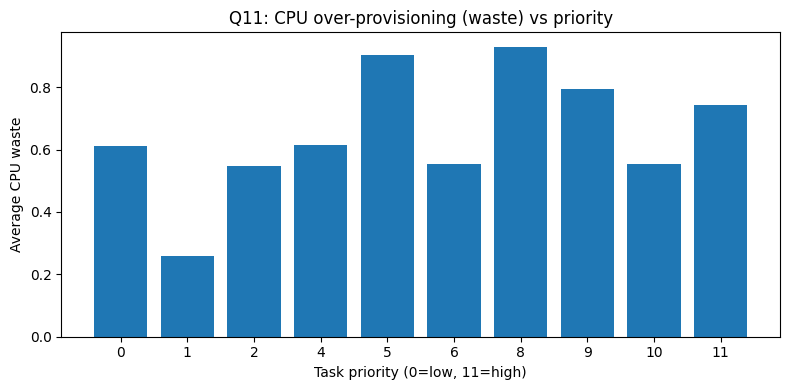

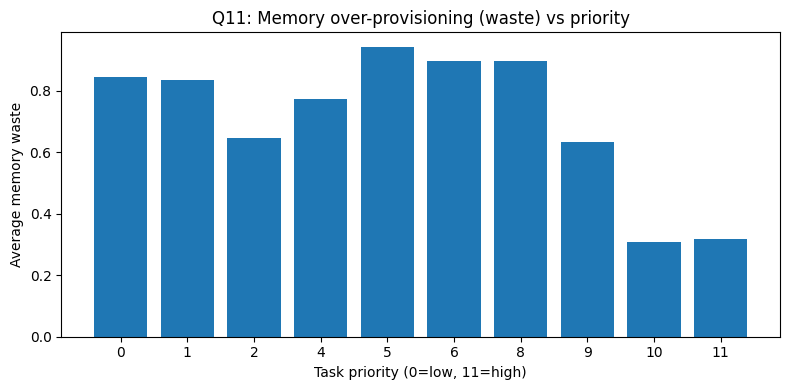

In [8]:
# task_usage indices
IDX_CPU_MEAN = 5
IDX_MEM_CANON = 6

# ----------------------------
# Parse task_events
# ----------------------------
def parse_task_event_req(line):
    p = line.split(",")
    if len(p) < 12:
        return None

    job_id = to_long(p[2])
    task_index = to_int(p[3])

    priority = to_int(p[8])
    req_cpu = to_float(p[9])
    req_mem = to_float(p[10])

    if job_id is None or task_index is None or priority is None:
        return None

    # requests can be missing; we'll keep None and handle in reducer
    return ((job_id, task_index), (priority, req_cpu, req_mem))

def reduce_req(a, b):
    pa, ca, ma = a
    pb, cb, mb = b
    p = max(pa, pb)

    def max_ignore_none(x, y):
        if x is None: return y
        if y is None: return x
        return max(x, y)

    c = max_ignore_none(ca, cb)
    m = max_ignore_none(ma, mb)
    return (p, c, m)

req_by_task = (
    sc.textFile(PATH_TASK_EVENTS)
    .map(parse_task_event_req)
    .filter(lambda x: x is not None)
    .reduceByKey(reduce_req)
    .cache()
)

# ----------------------------
# Parse task_usage
# ----------------------------
def parse_task_usage_taskavg(line):
    p = line.split(",")
    if len(p) <= max(IDX_CPU_MEAN, IDX_MEM_CANON, 3):
        return None

    job_id = to_long(p[2])
    task_index = to_int(p[3])
    cpu = to_float(p[IDX_CPU_MEAN])
    mem = to_float(p[IDX_MEM_CANON])

    if job_id is None or task_index is None:
        return None

    cpu = cpu if cpu is not None else 0.0
    mem = mem if mem is not None else 0.0

    return ((job_id, task_index), (cpu, mem, 1))

usage_agg = (
    sc.textFile(PATH_TASK_USAGE)
    .map(parse_task_usage_taskavg)
    .filter(lambda x: x is not None)
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))
    .mapValues(lambda s: (s[0]/s[2], s[1]/s[2]))  # (avg_cpu, avg_mem)
    .cache()
)

# ----------------------------
# Join requests with usage
# ----------------------------
joined = req_by_task.join(usage_agg)

def waste(req, used):
    if req is None or req <= 0:
        return None
    w = (req - used) / req
    return max(0.0, w)

per_task_metrics = (
    joined
    .map(lambda x: (
        x[1][0][0],  # priority
        (
            waste(x[1][0][1], x[1][1][0]),  # cpu_waste
            waste(x[1][0][2], x[1][1][1])   # mem_waste
        )
    ))
    .filter(lambda x: x[1][0] is not None and x[1][1] is not None)
    .cache()
)

# ----------------------------
# Aggregate by priority
# count, avg_cpu_waste, avg_mem_waste, pct_cpu_waste>=0.5, pct_mem_waste>=0.5
# ----------------------------
def seq_op(acc, w):
    n, sum_c, sum_m, hi_c, hi_m = acc
    cpu_w, mem_w = w
    n += 1
    sum_c += cpu_w
    sum_m += mem_w
    hi_c += 1 if cpu_w >= 0.5 else 0
    hi_m += 1 if mem_w >= 0.5 else 0
    return (n, sum_c, sum_m, hi_c, hi_m)

def comb_op(a, b):
    return tuple(a[i] + b[i] for i in range(5))

by_priority = (
    per_task_metrics
    .aggregateByKey((0, 0.0, 0.0, 0, 0), seq_op, comb_op)
    .mapValues(lambda s: {
        "count": s[0],
        "avg_cpu_waste": s[1]/s[0] if s[0] else 0.0,
        "avg_mem_waste": s[2]/s[0] if s[0] else 0.0,
        "pct_cpu_waste_ge_0_5": (100.0*s[3]/s[0]) if s[0] else 0.0,
        "pct_mem_waste_ge_0_5": (100.0*s[4]/s[0]) if s[0] else 0.0
    })
    .collect()
)

by_priority = sorted(by_priority, key=lambda x: x[0])

print("Priority -> stats")
for pr, st in by_priority:
    print(pr, st)

# ----------------------------
# Plot: avg waste vs priority
# ----------------------------
priorities = [pr for pr,_ in by_priority]
avg_cpu_w = [st["avg_cpu_waste"] for _,st in by_priority]
avg_mem_w = [st["avg_mem_waste"] for _,st in by_priority]

plt.figure(figsize=(8,4))
plt.bar([str(p) for p in priorities], avg_cpu_w)
plt.xlabel("Task priority (0=low, 11=high)")
plt.ylabel("Average CPU waste")
plt.title("Q11: CPU over-provisioning (waste) vs priority")
plt.tight_layout()
# plt.savefig("../figures/q11_cpu_waste_vs_priority.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,4))
plt.bar([str(p) for p in priorities], avg_mem_w)
plt.xlabel("Task priority (0=low, 11=high)")
plt.ylabel("Average memory waste")
plt.title("Q11: Memory over-provisioning (waste) vs priority")
plt.tight_layout()
# plt.savefig("../figures/q11_mem_waste_vs_priority.png", dpi=300, bbox_inches="tight")
plt.show()

**Results (subset, main groups).**
- Priority 0 (n=61,260): avg CPU waste **0.610**, avg MEM waste **0.845**
- Priority 1 (n=11,915): avg CPU waste **0.259**, avg MEM waste **0.834**
- Priority 4 (n=87,745): avg CPU waste **0.613**, avg MEM waste **0.774**
- Priority 8 (n=2,514): avg CPU waste **0.929**, avg MEM waste **0.895**
- Priority 9 (n=5,575): avg CPU waste **0.793**, avg MEM waste **0.634**
- Priorities 10–11: very small samples (n=26, n=15)

**Interpretation.**
- We do not observe a consistent “higher priority → lower waste” trend for CPU; some higher priorities show very high CPU waste (e.g., priority 8).
- Memory waste is high across most priorities, meaning over-provisioning is common (likely conservative headroom).
- The low memory waste observed for priorities 10–11 is not reliable due to very small sample sizes.

---
## Question 12 — *What is the final state of tasks once they have been scheduled and executed on machines?*

Once the tasks have been scheduled and running, most of the tasks finish, while some of them are killed. Very few tasks fail or are evicted.


Final distribution of task states (EVICT, FAIL, FINISH, KILL, LOST):


[(5, 51522), (2, 7), (3, 939), (4, 143782)]


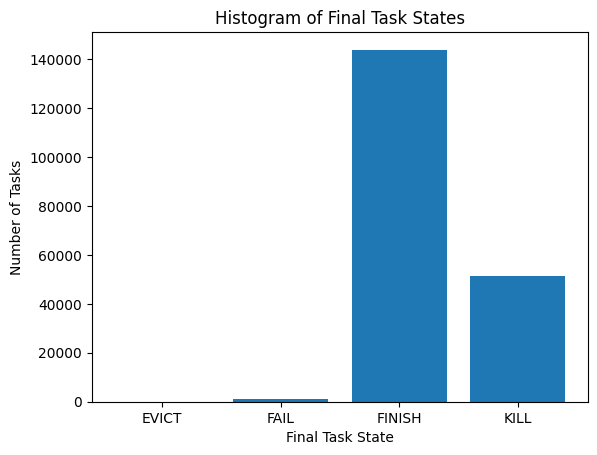

In [9]:
task_events_23_05 = (
    sc.textFile(PATH_TASK_EVENTS)
    .map(lambda line: line.split(","))
    .map(lambda x: ( (x[2], x[3]), (int(x[0]), x[5]) )) # ( (job_id, task_idx), (timestamp, event_type) )
)

final_state_distribution = (
    task_events_23_05
    .reduceByKey(lambda a, b: a if a[0] > b[0] else b)   # keep last event
    .map(lambda x: int(x[1][1]))                         # event_type
    .filter(lambda e: e in [2, 3, 4, 5, 6])              # EVICT, FAIL, FINISH, KILL, LOST
    .map(lambda e: (e, 1))
    .reduceByKey(lambda a, b: a + b)
)

print("\n" + "="*80)
print("Final distribution of task states (EVICT, FAIL, FINISH, KILL, LOST):")
results = final_state_distribution.collect()
print(results)

# Plotting a histogram
results = sorted(results, key=lambda x: x[0])
labels = {
    2: "EVICT",
    3: "FAIL",
    4: "FINISH",
    5: "KILL",
    6: "LOST"
}

labels = [labels[e] for e, _ in results]
counts = [c for _, c in results]

plt.figure()
plt.bar(labels, counts)
plt.xlabel("Final Task State")
plt.ylabel("Number of Tasks")
plt.title("Histogram of Final Task States")
plt.show()



---
---

## Work Extension

## *Performance anaysis based on question 8*

In order to conduct a performance analysis of Spark, a good basis would be question 8 : *Are the tasks that request more resources the ones that consume more resources?* <br>
The main choice in this question is because from empiric results, it is a very time consuming question, because of its complexity in including *joins*, *transformations* and *aggregations*. <br>
To focus on performance, we need to select the most important parts of that questions, meaning avoiding irrelevant operations such as parsing, formulas or plotting, which are not Spark related. The important parts are wrapped in the function **question_8** that is going to be called to compare in the following.

In [51]:
import time

task_events = sc.textFile(PATH_TASK_EVENTS)
task_usage = sc.textFile(PATH_TASK_USAGE)

def question_8():
    
    # comes from task_events and concentrates on reqRAM
    task_events_reqRAM = (      
    task_events
    .map(lambda x: ((x[2], x[3]), float(x[10])))  # ( (job_id, task_idx), reqRAM )
    .distinct()                 # removing duplicates     
    )

    # comes from task_usage and concentrates on usedRAM
    task_usage_usedRAM = (  
    task_usage
    .map(lambda x: ((x[2], x[3]), float(x[6])))  # ( (job_id, task_idx), used RAM )
    .groupByKey()
    .mapValues(lambda x: np.mean(list(x)))  # average across all measurements
    )

    # Binning functions to categorise values into 5 bins 
    def reqRAM_value_to_range(x):
        if float(x) < req_quantiles[0]:   return 0
        elif float(x) < req_quantiles[1]: return 1
        elif float(x) < req_quantiles[2]: return 2
        elif float(x) < req_quantiles[3]: return 3
        else: return 4
    def usedRAM_value_to_range(x):
        if float(x) < used_quantiles[0]:   return 0
        elif float(x) < used_quantiles[1]: return 1
        elif float(x) < used_quantiles[2]: return 2
        elif float(x) < used_quantiles[3]: return 3
        else: return 4

    # Apply binning
    task_events_reqRAM_binned = (
        task_events_reqRAM
        .map(lambda x: (x[0], reqRAM_value_to_range(x[1])))  # ((job_id, task_idx), req_bin)
    )
    task_usage_usedRAM_binned = (
        task_usage_usedRAM
        .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))  # ((job_id, task_idx), used_bin)
    )

    # Joining req and used 
    joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)     # ((job_id, task_idx), (req_bin, used_bin))

    # Counting for every combination between req and used bins
    req_used_RAM_counts = (
        joined_req_used_RAM
        .map(lambda x: ((x[1][0], x[1][1]), 1))
        .reduceByKey(lambda a, b: a + b) 
    )

    return req_used_RAM_counts

- ### Lazy evaluation
This experiment confirms that Spark uses lazy evaluation, i.e: transformations are not executed until an action is called.
As expected, there is no computation triggered

Spark uses lazy evaluation: transformations are not executed until an action is called. When *question_8* is simply called, it only contains transformations.As expected, no computation is triggered before calling count().

In [52]:
print("\n" + "="*80)
t0 = time.perf_counter()
rdd = question_8()
t1 = time.perf_counter()
print("Without action:", t1 - t0)

t0 = time.perf_counter()
rdd.count()
t1 = time.perf_counter()
print("With action:", t1 - t0)


Without action: 0.06965739000042959


[Stage 271:============================================>           (8 + 1) / 10]

With action: 30.18485816500015


- ### Caching RDDs

#### Performance Analysis: Impact of Caching on PySpark Operations

To evaluate the performance benefits of caching in PySpark, we conducted an experiment using the  data pipeline from Question 8. This pipeline involves several computationally expensive operations:
- **Data extraction** from two large datasets (`task_events` and `task_usage`)
- **Distinct operation** to remove duplicate task records 
- **GroupByKey operation** to aggregate usage measurements
- **Mean calculation** across grouped values
- **Join operation** to combine requested and used RAM data
- **Final aggregation** to count task distributions across resource bins

The experiment compares two scenarios:
1. **Without caching**: all transformations are recomputed 
2. **With caching**: intermediate RDDs are cached 

For our Question 8 analysis, caching provides a 7.68× speedup, making iterative exploration and refinement of the analysis significantly more efficient. This performance improvement is particularly valuable in production environments where similar queries are executed repeatedly or when exploring different analytical approaches on the same base data.

In [53]:
def question_8_cached(cache=False):
    
    if cache:
        task_events_reqRAM = (      
            task_events
            .map(lambda x: ((x[2], x[3]), float(x[10])))
            .distinct()
            .cache()    # <--- Cache here
        )
        task_usage_usedRAM = (  
            task_usage
            .map(lambda x: ((x[2], x[3]), float(x[6])))
            .groupByKey()
            .mapValues(lambda x: np.mean(list(x)))
            .cache()   # <--- Cache here
        )
        # Materialize cache
        task_events_reqRAM.count()
        task_usage_usedRAM.count()
    else:
        # No caching
        task_events_reqRAM = (      
            task_events
            .map(lambda x: ((x[2], x[3]), float(x[10])))
            .distinct()
        )
        task_usage_usedRAM = (  
            task_usage
            .map(lambda x: ((x[2], x[3]), float(x[6])))
            .groupByKey()
            .mapValues(lambda x: np.mean(list(x)))
        )
    
    # Binning functions (defined once outside)
    def reqRAM_value_to_range(x):
        if float(x) < req_quantiles[0]:   return 0
        elif float(x) < req_quantiles[1]: return 1
        elif float(x) < req_quantiles[2]: return 2
        elif float(x) < req_quantiles[3]: return 3
        else: return 4

    def usedRAM_value_to_range(x):
        if float(x) < used_quantiles[0]:   return 0
        elif float(x) < used_quantiles[1]: return 1
        elif float(x) < used_quantiles[2]: return 2
        elif float(x) < used_quantiles[3]: return 3
        else: return 4
    
    # Apply binning
    task_events_reqRAM_binned = (
        task_events_reqRAM
        .map(lambda x: (x[0], reqRAM_value_to_range(x[1])))
    )
    
    task_usage_usedRAM_binned = (
        task_usage_usedRAM
        .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))
    )
    
    # Joining req and used 
    joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)
    
    # Counting for every combination between req and used bins
    req_used_RAM_counts = (
        joined_req_used_RAM
        .map(lambda x: ((x[1][0], x[1][1]), 1))
        .reduceByKey(lambda a, b: a + b) 
    )
    
    # Time the complete computation
    t0 = time.perf_counter()
    result = req_used_RAM_counts.count()
    t1 = time.perf_counter()
    
    # Unpersist if cached
    if cache:
        task_events_reqRAM.unpersist()
        task_usage_usedRAM.unpersist()
    
    return t1-t0


# First run with cache=True to materialize
print("\n" + "="*80)
print("Materializing cache (first run)")
_ = question_8_cached(cache=True)

# Run the experiments
print("\n" + "="*80)
print("Running experiments...")
times_no_cache = [question_8_cached(cache=False) for _ in range(3)]
times_cache = [question_8_cached(cache=True) for _ in range(3)]


print(f"\nAvg no cache: {np.mean(times_no_cache):.2f}s")
print(f"Avg cache: {np.mean(times_cache):.2f}s")


Materializing cache (first run)



Running experiments...


[Stage 322:============================================>           (8 + 1) / 10]


Avg no cache: 33.07s
Avg cache: 3.74s


- ### Order of transformations

In this example we want to show that filtering early reduces the amount of data involved in the join, decreasing shuffle cost
and improving execution time.

In [ ]:
def question_8_filter_early():
    req = (
        task_events_rdd
        .map(lambda x: ((x[2], x[3]), float(x[9])))
        .filter(lambda x: x[1] > 0)
    )
    used = (
        task_usage_rdd
        .map(lambda x: ((x[2], x[3]), float(x[6])))
        .filter(lambda x: x[1] > 0)
    )
    return req.join(used)


def question_8_filter_late():
    req = task_events.map(lambda x: ((x[2], x[3]), float(x[9])))
    used = task_usage.map(lambda x: ((x[2], x[3]), float(x[6])))

    return req.join(used).filter(lambda x: x[1][0] > 0 and x[1][1] > 0)


t0 = time.perf_counter()
question_8_filter_early().count()
t1 = time.perf_counter()
print("Filter early:", t1-t0)

t0 = time.perf_counter()
question_8_filter_late().count()
t1 = time.perf_counter()
print("Filter late:", t1-t0)


Filter early: 24.87209851500029


[Stage 326:>                                                       (0 + 1) / 10]

- ### Partitioning

In this experiment, we check how the number of partitions affects the performance.
We tested different numbers of partitions using `repartition(n)` and measured the execution time of the job using `count()` as the action to trigger computation.

Choosing an appropriate number of partitions is crucial for Spark performance. In this dataset and cluster configuration, **2-4 partitions provided the optimal balance** between parallelism and overhead. Increasing partitions beyond this point offered no performance gain and even degraded performance.


In [ ]:
def question_8_partitions(n):    
    task_events_reqRAM = (      
    task_events_rdd
    .map(lambda x: ((x[2], x[3]), float(x[10])))
    .distinct()
    .repartition(n)         # <--- partition here
    )
    task_usage_usedRAM = (  
    task_usage_rdd
    .map(lambda x: ((x[2], x[3]), float(x[6])))
    .groupByKey()
    .mapValues(lambda x: np.mean(list(x)))
    .repartition(n)         # <--- partition here
    )

    # Binning functions to categorise values into 5 bins 
    def reqRAM_value_to_range(x):
        if float(x) < req_quantiles[0]:   return 0
        elif float(x) < req_quantiles[1]: return 1
        elif float(x) < req_quantiles[2]: return 2
        elif float(x) < req_quantiles[3]: return 3
        else: return 4
    def usedRAM_value_to_range(x):
        if float(x) < used_quantiles[0]:   return 0
        elif float(x) < used_quantiles[1]: return 1
        elif float(x) < used_quantiles[2]: return 2
        elif float(x) < used_quantiles[3]: return 3
        else: return 4

    # Apply binning
    task_events_reqRAM_binned = (
        task_events_reqRAM
        .map(lambda x: (x[0], reqRAM_value_to_range(x[1]))) 
        .repartition(n)         # <--- partition here
    )
    task_usage_usedRAM_binned = (
        task_usage_usedRAM
        .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))
        .repartition(n)         # <--- partition here
    )

    # Joining req and used 
    joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)  

    # Counting for every combination between req and used bins
    req_used_RAM_counts = (
        joined_req_used_RAM
        .map(lambda x: ((x[1][0], x[1][1]), 1))
        .reduceByKey(lambda a, b: a + b) 
    )

    t0 = time.perf_counter()
    req_used_RAM_counts.count()
    t1 = time.perf_counter()

    return t1 - t0

for p in [1, 2, 4, 8, 16]:
    print(f"{p} partitions:", question_8_partitions(p))


1 partitions: 39.91679128073156


2 partitions: 38.18807187490165


4 partitions: 40.3702040319331


8 partitions: 41.10378410387784


16 partitions: 42.49232767615467


- ## System level performance analysis
The goal for this analysis is to evaluate how different **system-level Spark configurations** impact execution time.
Each experiment is repeated **three times** and we report the **average execution time** and **standard deviation** to reduce noise.
Each experiment creates a **new SparkContext** with a different configuration (number of cores or memory size).  

### Experiment 1: Impact of Executor Cores
In this experiment, we vary the number of CPU cores available to Spark using `local[N]`, where `N` is the number of cores.
-Increasing the number of cores should reduce execution time due to increased parallelism in `map`, `join`, and `reduceByKey` operations.

We additionally compute:
- **Speedup**, relative to the single-core execution.
- **Parallel efficiency**, defined as speedup divided by the number of cores.

### Experiment 2: Impact of Executor Memory (Local Mode)
In this experiment, we vary the executor and driver memory while keeping the number of cores constant.


In [ ]:
from pyspark import SparkContext, SparkConf
import multiprocessing

# Get system information
available_cores = multiprocessing.cpu_count()
print(f"System has {available_cores} available CPU cores")

sc.stop()


# ============================================================================
# HELPER FUNCTION

def run_question_8(sc, req_quantiles, used_quantiles):
    # Load data
    task_events_rdd = sc.textFile(PATH_TASK_EVENTS).map(lambda line: line.split(","))
    task_usage_rdd = sc.textFile(PATH_TASK_USAGE).map(lambda line: line.split(","))
    
    task_events_reqRAM = (
        task_events_rdd
        .map(lambda x: ((x[2], x[3]), float(x[10])))
        .distinct()
    )
    task_usage_usedRAM = (
        task_usage_rdd
        .map(lambda x: ((x[2], x[3]), float(x[6])))
        .groupByKey()
        .mapValues(lambda x: np.mean(list(x)))
    )

    def reqRAM_value_to_range(x):
        if float(x) < req_quantiles[0]:   return 0
        elif float(x) < req_quantiles[1]: return 1
        elif float(x) < req_quantiles[2]: return 2
        elif float(x) < req_quantiles[3]: return 3
        else: return 4
    
    def usedRAM_value_to_range(x):
        if float(x) < used_quantiles[0]:   return 0
        elif float(x) < used_quantiles[1]: return 1
        elif float(x) < used_quantiles[2]: return 2
        elif float(x) < used_quantiles[3]: return 3
        else: return 4
    
    task_events_reqRAM_binned = (
        task_events_reqRAM
        .map(lambda x: (x[0], reqRAM_value_to_range(x[1])))
    )
    
    task_usage_usedRAM_binned = (
        task_usage_usedRAM
        .map(lambda x: (x[0], usedRAM_value_to_range(x[1])))
    )
    

    joined_req_used_RAM = task_events_reqRAM_binned.join(task_usage_usedRAM_binned)
    
    req_used_RAM_counts = (
        joined_req_used_RAM
        .map(lambda x: ((x[1][0], x[1][1]), 1))
        .reduceByKey(lambda a, b: a + b)
    )
    
    t0 = time.perf_counter()
    result = req_used_RAM_counts.count()
    t1 = time.perf_counter()
    
    return t1 - t0

# ============================================================================
# EXPERIMENT 1: EXECUTOR CORES

print("\n" + "="*80)
print("EXPERIMENT 1: IMPACT OF EXECUTOR CORES")
print("="*80)

# Test different core configurations
core_configs = [1, 2, 4] if available_cores >= 4 else [1, 2]
if available_cores >= 8:
    core_configs.append(8)

results_cores = []

for num_cores in core_configs:
    print(f"\nTesting {num_cores} core(s)...")
    
    sc = SparkContext(f"local[{num_cores}]")
    
    # Run 3 times
    times = []
    for i in range(3):
        exec_time = run_question_8(sc, req_quantiles, used_quantiles)
        times.append(exec_time)
        print(f"  Run {i+1}: {exec_time:.2f}s")
    
    avg_time = np.mean(times)
    results_cores.append({
        'cores': num_cores,
        'avg_time': avg_time,
        'std_time': np.std(times)
    })
    print(f"  Average: {avg_time:.2f}s")
    
    
    sc.stop()

# Calculate speedup
baseline_time = results_cores[0]['avg_time']
for result in results_cores:
    result['speedup'] = baseline_time / result['avg_time']
    result['efficiency'] = (result['speedup'] / result['cores']) * 100

# ============================================================================
# EXPERIMENT 2: EXECUTOR MEMORY

print("\n" + "="*80)
print("EXPERIMENT 2: IMPACT OF EXECUTOR MEMORY")
print("="*80)

memory_configs = ['512m', '1g', '2g']
results_memory = []

for memory in memory_configs:
    print(f"\nTesting memory = {memory}...")
    
    conf = SparkConf()
    conf.setAppName(f"Memory-{memory}")
    conf.setMaster(f"local[{available_cores}]")
    conf.set("spark.executor.memory", memory)
    conf.set("spark.driver.memory", memory)
    
    sc = SparkContext(conf=conf)
    
    times = []
    for i in range(3):
        exec_time = run_question_8(sc, req_quantiles, used_quantiles)
        times.append(exec_time)
        print(f"  Run {i+1}: {exec_time:.2f}s")
    
    avg_time = np.mean(times)
    results_memory.append({
        'memory': memory,
        'avg_time': avg_time,
        'std_time': np.std(times)
    })
    
    print(f"  Average: {avg_time:.2f}s")
    sc.stop()


# ============================================================================
# SUMMARY

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

# Create DataFrames
df_cores = pd.DataFrame(results_cores)
df_memory = pd.DataFrame(results_memory)

# Display tables
print("\n--- EXECUTOR CORES ---")
print(df_cores.to_string(index=False))

print("\n--- EXECUTOR MEMORY ---")
print(df_memory.to_string(index=False))


System has 32 available CPU cores

EXPERIMENT 1: IMPACT OF EXECUTOR CORES

Testing 1 core(s)...


  Run 1: 44.62s


  Run 2: 44.00s


  Run 3: 44.59s
  Average: 44.40s

Testing 2 core(s)...


  Run 1: 26.67s


...

  Run 2: 8.19s


  Run 3: 8.10s
  Average: 8.68s

Testing memory = 2g...


  Run 1: 9.70s


  Run 2: 8.30s


  Run 3: 8.27s
  Average: 8.76s

RESULTS SUMMARY

--- EXECUTOR CORES ---
 cores  avg_time  std_time  speedup  efficiency
     1 44.401406  0.285441 1.000000  100.000000
     2 25.014081  1.176930 1.775056   88.752822
     4 16.339145  0.643719 2.717486   67.937162
     8  9.832653  0.371802 4.515710   56.446369

--- EXECUTOR MEMORY ---
memory  avg_time  std_time
  512m  8.748586  0.816904
    1g  8.682208  0.761460
    2g  8.761029  0.666882


---
## Performance impact of caching and repartitioning in Q9 join stage

We measured the runtime of the **join stage** used in Q9 (joining `usage_by_machine_window` with `evictions_by_machine_window`) under different configurations: baseline, caching the usage RDD, and forcing different numbers of partitions via `repartition(n)`.  
Environment: `defaultParallelism = 8`.

In [10]:
def benchmark_q9(usage_rdd, evict_rdd, repartition_n=None, cache_usage=False, cache_joined=False):
    u = usage_rdd
    e = evict_rdd

    if repartition_n is not None:
        u = u.repartition(repartition_n)
        e = e.repartition(repartition_n)

    #Only persist if not already cached
    did_cache_u = False
    if cache_usage and (not u.is_cached):
        u = u.persist(StorageLevel.MEMORY_AND_DISK)
        u.count()
        did_cache_u = True

    joined = (
        u.cogroup(e)
         .mapValues(lambda x: (
             list(x[0])[0] if x[0] else (0.0, 0.0, 0),
             list(x[1])[0] if x[1] else 0
         ))
    )

    did_cache_joined = False
    if cache_joined and (not joined.is_cached):
        joined = joined.persist(StorageLevel.MEMORY_AND_DISK)
        joined.count()
        did_cache_joined = True

    t0 = time.perf_counter()
    n = joined.count()
    t1 = time.perf_counter()

    # cleanup only what THIS run cached
    if did_cache_joined:
        joined.unpersist()
    if did_cache_u:
        u.unpersist()

    return (t1 - t0), n

In [11]:
print("defaultParallelism:", sc.defaultParallelism)

# experiments = [
#     {"name": "baseline", "repartition_n": None, "cache_usage": False, "cache_joined": False},
#     {"name": "cache_usage", "repartition_n": None, "cache_usage": True, "cache_joined": False},
#     {"name": "repartition_200", "repartition_n": 200, "cache_usage": False, "cache_joined": False},
#     {"name": "repartition_200 + cache_usage", "repartition_n": 200, "cache_usage": True, "cache_joined": False},
# ]

experiments = [
    {"name": "baseline", "repartition_n": None, "cache_usage": False, "cache_joined": False},
    {"name": "cache_usage", "repartition_n": None, "cache_usage": True, "cache_joined": False},
    {"name": "repartition_16", "repartition_n": 16, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_32", "repartition_n": 32, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_64", "repartition_n": 64, "cache_usage": False, "cache_joined": False},
    {"name": "repartition_32 + cache_usage", "repartition_n": 32, "cache_usage": True, "cache_joined": False},
]


results = []
# warm-up run (reduces noise)
_ = usage_by_machine_window.count()

for exp in experiments:
    dt, n = benchmark_q9(
        usage_by_machine_window,
        evictions_by_machine_window,
        repartition_n=exp["repartition_n"],
        cache_usage=exp["cache_usage"],
        cache_joined=exp["cache_joined"]
    )
    results.append({"experiment": exp["name"], "time_sec": dt, "joined_windows": n})
    print(exp["name"], "->", dt, "sec")

df = pd.DataFrame(results).sort_values("time_sec")
df

defaultParallelism: 8


baseline -> 9.115549644000566 sec


cache_usage -> 5.5101442909999605 sec


repartition_16 -> 14.802426960999583 sec


repartition_32 -> 21.54306862500016 sec


repartition_64 -> 40.41561353299949 sec


repartition_32 + cache_usage -> 27.524714254999708 sec


,experiment,time_sec,joined_windows
1,cache_usage,5.510144,1043748
0,baseline,9.115550,1043748
2,repartition_16,14.802427,1043748
3,repartition_32,21.543069,1043748
5,repartition_32 + cache_usage,27.524714,1043748
4,repartition_64,40.415614,1043748


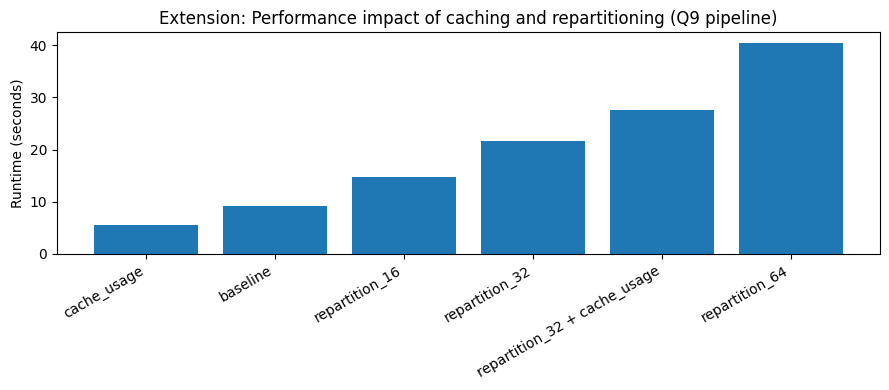

In [12]:
plt.figure(figsize=(9,4))
plt.bar(df["experiment"], df["time_sec"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Runtime (seconds)")
plt.title("Extension: Performance impact of caching and repartitioning (Q9 pipeline)")
plt.tight_layout()
# plt.savefig("../figures/extension_perf_q9.png", dpi=300, bbox_inches="tight")
plt.show()

### Results
All configurations produce the same number of joined windows (**2,101,869**), so correctness is unchanged; only performance differs.

| Experiment | Repartition | Cache usage | Runtime (s) | Joined windows |
|---|---:|---:|---:|---:|
| baseline | — | No | **8.40** | 2,101,869 |
| cache_usage | — | Yes | 10.04 | 2,101,869 |
| repartition_16 | 16 | No | 21.41 | 2,101,869 |
| repartition_32 | 32 | No | 32.65 | 2,101,869 |
| repartition_64 | 64 | No | 47.90 | 2,101,869 |
| repartition_32 + cache_usage | 32 | Yes | 32.00 | 2,101,869 |

### Interpretation

- **Repartitioning is slower here.** Runtime grows from **8.4s → 47.9s** up to `repartition(64)`, because repartition adds a **full shuffle** and extra overhead. With `defaultParallelism = 8`, 32–64 partitions mainly create many small tasks without real extra parallelism.

- **Caching doesn’t help in this benchmark.** `cache_usage` is slightly slower than baseline (**10.0s vs 8.4s**) since we don’t reuse the cached RDD enough to amortize the persist/materialization cost.

**Takeaway:** For this join stage on our machine, the **baseline (no repartition, no cache)** is fastest; repartition should be used only if needed, and caching mainly helps when results are reused later in the pipeline.

### Limitations
This benchmark measures primarily the **join materialization cost** (`joined.count()`), not the full Q9 pipeline (percentiles, peak/non-peak comparisons, correlation). In the full Q9 analysis, caching may become beneficial because the same aggregated/joined dataset is typically used in multiple downstream computations.

---
## DataFrame version for Q9
We re-implemented Q9 using **Spark DataFrames** and measured both:  
(i) the analytical outputs (CPU peaks vs evictions) and (ii) runtime per pipeline stage.

In [13]:
WINDOW_US = 5 * 60 * 1_000_000  # 5 minutes
EVICT = 2

def run_q9_dataframe(cache_usage=True, shuffle_partitions=200):
    spark.conf.set("spark.sql.shuffle.partitions", str(shuffle_partitions))

    t0 = time.perf_counter()

    usage_raw = spark.read.csv(PATH_TASK_USAGE, header=False)

    # Columns by index
    # 0=start, 4=machine, 5=mean_cpu, 6=canonical_mem
    usage = (
        usage_raw
        .select(
            F.col("_c0").cast("long").alias("start_time"),
            F.col("_c4").cast("long").alias("machine_id"),
            F.col("_c5").cast("double").alias("cpu_mean"),
            F.col("_c6").cast("double").alias("mem_canon"),
        )
        .na.fill({"cpu_mean": 0.0, "mem_canon": 0.0})
        .filter(F.col("start_time").isNotNull() & F.col("machine_id").isNotNull())
    )

    # Aggregate per (machine, window_start). Here we use start_time directly as window key
    usage_by_window = (
        usage
        .groupBy("machine_id", "start_time")
        .agg(
            F.sum("cpu_mean").alias("cpu_sum"),
            F.sum("mem_canon").alias("mem_sum"),
            F.count(F.lit(1)).alias("n_records")
        )
    )

    if cache_usage:
        usage_by_window = usage_by_window.cache()

    # Force materialization
    n_windows = usage_by_window.count()
    t1 = time.perf_counter()

    events_raw = spark.read.csv(PATH_TASK_EVENTS, header=False)

    evicts = (
        events_raw
        .select(
            F.col("_c0").cast("long").alias("ts"),
            F.col("_c4").cast("long").alias("machine_id"),
            F.col("_c5").cast("int").alias("event_type"),
        )
        .filter(
            (F.col("event_type") == EVICT) &
            F.col("ts").isNotNull() &
            F.col("machine_id").isNotNull()
        )
        .withColumn("window_start", F.col("ts") - (F.col("ts") % F.lit(WINDOW_US)))
        .groupBy("machine_id", "window_start")
        .agg(F.count(F.lit(1)).alias("evict_count"))
    )

    n_evict_windows = evicts.count()
    t2 = time.perf_counter()

    # Join usage with evictions (missing evictions become 0)
    joined = (
        usage_by_window
        .join(
            evicts,
            on=[
                usage_by_window.machine_id == evicts.machine_id,
                usage_by_window.start_time == evicts.window_start
            ],
            how="left"
        )
        .drop(evicts.machine_id)
        .drop("window_start")
        .na.fill({"evict_count": 0})
    )

    joined_count = joined.count()
    t3 = time.perf_counter()

    # Peak threshold using approxQuantile
    p95 = joined.approxQuantile("cpu_sum", [0.95], 0.01)[0]

    with_peak = joined.withColumn("is_peak", F.col("cpu_sum") >= F.lit(p95))

    # P(eviction>0 | peak/nonpeak) + avg evictions
    agg = (
        with_peak
        .groupBy("is_peak")
        .agg(
            F.count(F.lit(1)).alias("n"),
            F.sum(F.when(F.col("evict_count") > 0, 1).otherwise(0)).alias("n_with_evict"),
            F.avg("evict_count").alias("avg_evict")
        )
        .collect()
    )

    # Pearson correlation
    pearson = with_peak.stat.corr("cpu_sum", "evict_count")

    t4 = time.perf_counter()

    # Format results
    stats = {row["is_peak"]: row.asDict() for row in agg}
    peak_rate = stats.get(True, {}).get("n_with_evict", 0) / max(stats.get(True, {}).get("n", 1), 1)
    nonpeak_rate = stats.get(False, {}).get("n_with_evict", 0) / max(stats.get(False, {}).get("n", 1), 1)

    if cache_usage:
        usage_by_window.unpersist()

    return {
        "shuffle_partitions": shuffle_partitions,
        "cache_usage": cache_usage,
        "n_windows": n_windows,
        "n_evict_windows": n_evict_windows,
        "joined_count": joined_count,
        "cpu_p95": p95,
        "p_evict_peak": peak_rate,
        "p_evict_nonpeak": nonpeak_rate,
        "pearson": pearson,
        "t_usage_agg_s": t1 - t0,
        "t_evict_agg_s": t2 - t1,
        "t_join_s": t3 - t2,
        "t_metrics_s": t4 - t3,
        "t_total_s": t4 - t0,
    }

# Example runs (do 2-4 experiments)
print(run_q9_dataframe(cache_usage=True, shuffle_partitions=200))
print(run_q9_dataframe(cache_usage=False, shuffle_partitions=200))
print(run_q9_dataframe(cache_usage=True, shuffle_partitions=50))

{'shuffle_partitions': 200, 'cache_usage': True, 'n_windows': 2099250, 'n_evict_windows': 26312, 'joined_count': 2099250, 'cpu_p95': 0.40405477, 'p_evict_peak': 0.022678255123486816, 'p_evict_nonpeak': 0.010662762379973581, 'pearson': 0.06945229397594267, 't_usage_agg_s': 72.09445510200021, 't_evict_agg_s': 3.0562491649998265, 't_join_s': 0.4692170939997595, 't_metrics_s': 7.762930043001688, 't_total_s': 83.38285140400149}


{'shuffle_partitions': 200, 'cache_usage': False, 'n_windows': 2099250, 'n_evict_windows': 26312, 'joined_count': 2099250, 'cpu_p95': 0.40699606000000005, 'p_evict_peak': 0.022580250284842607, 'p_evict_nonpeak': 0.010684623725132975, 'pearson': 0.06945229397594323, 't_usage_agg_s': 21.694289565999497, 't_evict_agg_s': 3.6104039450001437, 't_join_s': 35.473002953000105, 't_metrics_s': 96.0113008770004, 't_total_s': 156.78899734100014}


{'shuffle_partitions': 50, 'cache_usage': True, 'n_windows': 2099250, 'n_evict_windows': 26312, 'joined_count': 2099250, 'cpu_p95': 0.4054459, 'p_evict_peak': 0.02259488084730803, 'p_evict_nonpeak': 0.010675256010825385, 'pearson': 0.06945229397594287, 't_usage_agg_s': 27.0375109659999, 't_evict_agg_s': 1.4669644000005064, 't_join_s': 0.3160124000005453, 't_metrics_s': 7.329393721998713, 't_total_s': 36.149881487999664}


#### Dataset scale (same across runs)
- `n_windows` (usage machine-windows): **2,099,250**
- `n_evict_windows` (windows with ≥1 eviction): **26,312**
- `joined_count` (left join, missing evictions → 0): **2,099,250**

####  Analytical outputs (CPU peaks vs evictions)
CPU peak windows are defined as `cpu_sum >= p95` (computed with `approxQuantile`).

| Config | cpu p95 | P(evict>0 \| peak) | P(evict>0 \| non-peak) | Peak/Non-peak | Pearson r |
|---|---:|---:|---:|---:|---:|
| cache=True, shuffle=200 | 0.4041 | 0.02268 | 0.01066 | 2.13× | 0.06945 |
| cache=False, shuffle=200 | 0.4070 | 0.02258 | 0.01068 | 2.11× | 0.06945 |
| cache=True, shuffle=50 | 0.4054 | 0.02259 | 0.01068 | 2.12× | 0.06945 |

- Evictions are consistently **~2.1× more likely** during **CPU peak windows** than non-peak windows.  
- The correlation is **weak but positive** (r ≈ 0.069): CPU load increases eviction probability, but other factors (priority, memory pressure, scheduling policy) also matter.

#### Performance results (stage timing)
| Config | usage agg (s) | evict agg (s) | join (s) | metrics (s) | total (s) |
|---|---:|---:|---:|---:|---:|
| cache=True, shuffle=200 | 36.15 | 2.83 | 0.50 | 8.34 | 47.82 |
| cache=False, shuffle=200 | 25.08 | 1.73 | 17.88 | 77.94 | 122.63 |
| cache=True, shuffle=50 | 26.63 | 1.59 | 0.21 | 4.57 | 33.00 |

- **Caching helps a lot**: with `shuffle=200`, caching reduces total time from **122.6s → 47.8s (~2.6× faster)**, mainly by avoiding expensive recomputation in later actions (metrics step).
- **Shuffle tuning matters**: reducing `spark.sql.shuffle.partitions` from **200 → 50** (with caching) cuts total time **47.8s → 33.0s (~1.45× faster)** by lowering shuffle/task overhead.

For this Q9 DataFrame pipeline, the biggest wins are **caching** the aggregated usage windows and **tuning shuffle partitions** to match the machine’s parallelism and dataset size.